In [209]:
import pandas as pd
import numpy as np
import re
import pycountry
import matplotlib.pyplot as plt
import seaborn as sns

# import the data file
df_Data = pd.read_excel(
    r"D:\Projects\Data\Countries_Socioeconom_Profiles_Data\World_Development_Indicators.xlsx",
    sheet_name=0
)

# replace .. with nans
df_Data = df_Data.replace("..", np.nan)

# drop years with high persentage of nans
df_Data = df_Data.drop(columns=['2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]'])

# Year columns
year_cols = [f"{year} [YR{year}]" for year in range(2010, 2022)]

df_Data = df_Data.melt(
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

# Extract only the year
df_Data["Year"] = df_Data["Year"].str.extract(r"(\d{4})").astype(int)

# Make values numeric
df_Data["Value"] = pd.to_numeric(df_Data["Value"], errors="coerce")

# pivot df_Data
df_wide = df_Data.pivot(
    index=["Country Name", "Country Code", "Year"],
    columns="Series Name",
    values="Value"
).reset_index()

# normalize the names
df_wide.columns = (
    df_wide.columns
    .str.lower()
    .str.strip()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\s+", "_", regex=True)
)

rename_dict = {
    "Country Name": "country_name",
    "Country Code": "country_code",
    "Year": "year",
    
    "Access to electricity (% of population)": "access_to_electricity",
    "Agriculture, forestry, and fishing, value added (% of GDP)": "agriculture_value_added",
    "Broad money (% of GDP)": "broad_money",
    "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)": "co2_emissions_per_capita",
    "Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP)": "carbon_intensity_gdp",
    "Central government debt, total (% of GDP)": "government_debt",
    "Current health expenditure (% of GDP)": "health_expenditure",
    "Domestic credit to private sector (% of GDP)": "domestic_credit_private_sector",
    "Energy use (kg of oil equivalent per capita)": "energy_use_per_capita",
    "Exports of goods and services (% of GDP)": "exports",
    "Fertility rate, total (births per woman)": "fertility_rate",
    "Foreign direct investment, net inflows (% of GDP)": "fdi_inflows",
    "Forest area (% of land area)": "forest_area",
    "Fossil fuel energy consumption (% of total)": "fossil_fuel_consumption",
    "GDP growth (annual %)": "gdp_growth",
    "GDP per capita (constant 2015 US$)": "gdp_per_capita",
    "Gross capital formation (% of GDP)": "gross_capital_formation",
    "Imports of goods and services (% of GDP)": "imports",
    "Individuals using the Internet (% of population)": "internet_usage",
    "Industry (including construction), value added (% of GDP)": "industry_value_added",
    "Inflation, consumer prices (annual %)": "inflation",
    "Life expectancy at birth, total (years)": "life_expectancy",
    "Literacy rate, adult total (% of people ages 15 and above)": "literacy_rate",
    "Military expenditure (% of general government expenditure)": "military_expenditure",
    "Multidimensional poverty headcount ratio (World Bank) (% of population)": "multidimensional_poverty",
    "Population growth (annual %)": "population_growth",
    "Renewable electricity output (% of total electricity output)": "renewable_electricity",
    "Renewable energy consumption (% of total final energy consumption)": "renewable_energy",
    "Research and development expenditure (% of GDP)": "rd_expenditure",
    "School enrollment, primary (% gross)": "primary_school_enrollment",
    "Services, value added (% of GDP)": "services_value_added",
    "Trade (% of GDP)": "trade",
    "Unemployment, total (% of total labor force) (modeled ILO estimate)": "unemployment",
    "Urban population (% of total population)": "urban_population"
}

df_wide = df_wide.rename(columns=rename_dict)

# Retain only actual countries with valid ISO 3166-1 alpha-3 codes
valid_iso_codes = {country.alpha_3 for country in pycountry.countries}
df_countries = df_wide[df_wide['country_code'].isin(valid_iso_codes)].copy()

# calculate each country's overall percentage of missing data across all indicators and orders them from highest missingness to lowest.
feature_cols = df_countries.columns.difference(
    ["country_name", "country_code", "year"]
)

df_country_nan = (
    df_countries.groupby(["country_name", "country_code"])[feature_cols]
    .apply(lambda x: x.isna().sum().sum())
    .rename("nan_count")
    .reset_index()
)

# Total possible values per country
df_country_nan["total_values"] = (
    df_countries.groupby(["country_name", "country_code"])
    .size()
    .values * len(feature_cols)
)

# Percentage of missing values
df_country_nan["nan_percentage"] = (
    df_country_nan["nan_count"] /
    df_country_nan["total_values"]
)

df_country_nan = df_country_nan.sort_values(
    "nan_percentage",
    ascending=False
)

# delete country's with high persentage of nans
nan_per_delete = df_country_nan['nan_percentage'].quantile(q= 0.85)
country_to_delete = df_country_nan[df_country_nan['nan_percentage'] >= nan_per_delete]
country_to_delete_list = country_to_delete['country_name'].tolist()



# delete columns with high nans
nan_summary = (
    pd.DataFrame({
        "nan_count": df_countries.isna().sum(),
        "nan_percentage": df_countries.isna().mean()
    })
    .reset_index(names="Series Name")
    .sort_values("nan_percentage", ascending=False)
)

for country in country_to_delete_list:

    df_countries = df_countries[df_countries['country_name'] != country]

null_per_max = 0.5

Series_Name_delete = nan_summary[nan_summary['nan_percentage'] >= null_per_max]
Series_Name_delete_list = Series_Name_delete['Series Name'].tolist()
df_countries = df_countries.drop(columns=Series_Name_delete_list)

In [210]:
df_describe = df_countries.loc[:, 'access_to_electricity_of_population':'urban_population_of_total_population'].describe()
df_describe

Series Name,access_to_electricity_of_population,agriculture_forestry_and_fishing_value_added_of_gdp,broad_money_of_gdp,carbon_dioxide_co2_emissions_excluding_lulucf_per_capita_t_co2ecapita,carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp,current_health_expenditure_of_gdp,domestic_credit_to_private_sector_of_gdp,energy_use_kg_of_oil_equivalent_per_capita,exports_of_goods_and_services_of_gdp,fertility_rate_total_births_per_woman,...,life_expectancy_at_birth_total_years,military_expenditure_of_general_government_expenditure,population_growth_annual_,renewable_electricity_output_of_total_electricity_output,renewable_energy_consumption_of_total_final_energy_consumption,school_enrollment_primary_gross,services_value_added_of_gdp,trade_of_gdp,unemployment_total_of_total_labor_force_modeled_ilo_estimate,urban_population_of_total_population
count,2184.000000,2154.000000,1781.000000,2148.000000,2142.000000,2139.000000,1994.000000,1728.000000,1984.000000,2184.000000,...,2184.000000,1750.000000,2184.000000,2117.000000,2184.000000,1850.000000,2166.000000,1984.000000,2124.000000,2184.000000
mean,82.347115,10.728903,96.605770,4.632333,0.481104,6.362456,53.959839,2402.003415,41.765300,2.756436,...,71.492016,6.493788,1.324961,33.555803,31.893681,102.154369,55.471440,88.275220,7.897199,58.534505
std,27.299678,10.100060,667.318131,6.173257,0.409526,2.712920,44.501003,2867.799479,30.970385,1.384409,...,8.037471,5.336009,1.497868,31.524564,28.238267,12.324327,12.028650,55.750341,6.053096,22.633912
min,4.100000,0.000000,8.585482,0.001792,0.000590,1.543096,3.096598,71.687964,0.000000,0.756000,...,31.530000,0.002831,-10.927442,0.000000,0.000000,25.565756,0.000000,0.000000,0.100000,10.984310
25%,69.400000,2.392313,33.251200,0.685501,0.225890,4.275708,21.125094,606.585115,22.366567,1.663500,...,65.770000,2.888385,0.357824,6.189744,8.500000,97.437507,47.760381,53.257715,3.716250,40.002780
50%,99.200000,7.105493,51.223294,2.558994,0.350282,6.004436,41.442351,1451.302069,33.854517,2.270500,...,72.674000,4.929830,1.258048,22.207388,23.700000,101.073076,54.829123,76.251541,5.844500,60.271659
75%,100.000000,17.065236,74.574585,6.262987,0.584144,8.186075,70.055122,2872.669221,51.571072,3.650750,...,77.415848,8.632159,2.247920,59.508502,50.525000,106.753691,63.367001,105.529920,10.431250,76.577563
max,100.000000,44.330943,13309.489839,53.599259,2.976524,21.923731,269.837325,21456.066928,221.610060,7.640000,...,85.532683,40.640081,14.225399,100.000000,97.000000,183.989440,96.162595,442.620019,34.153000,100.000000


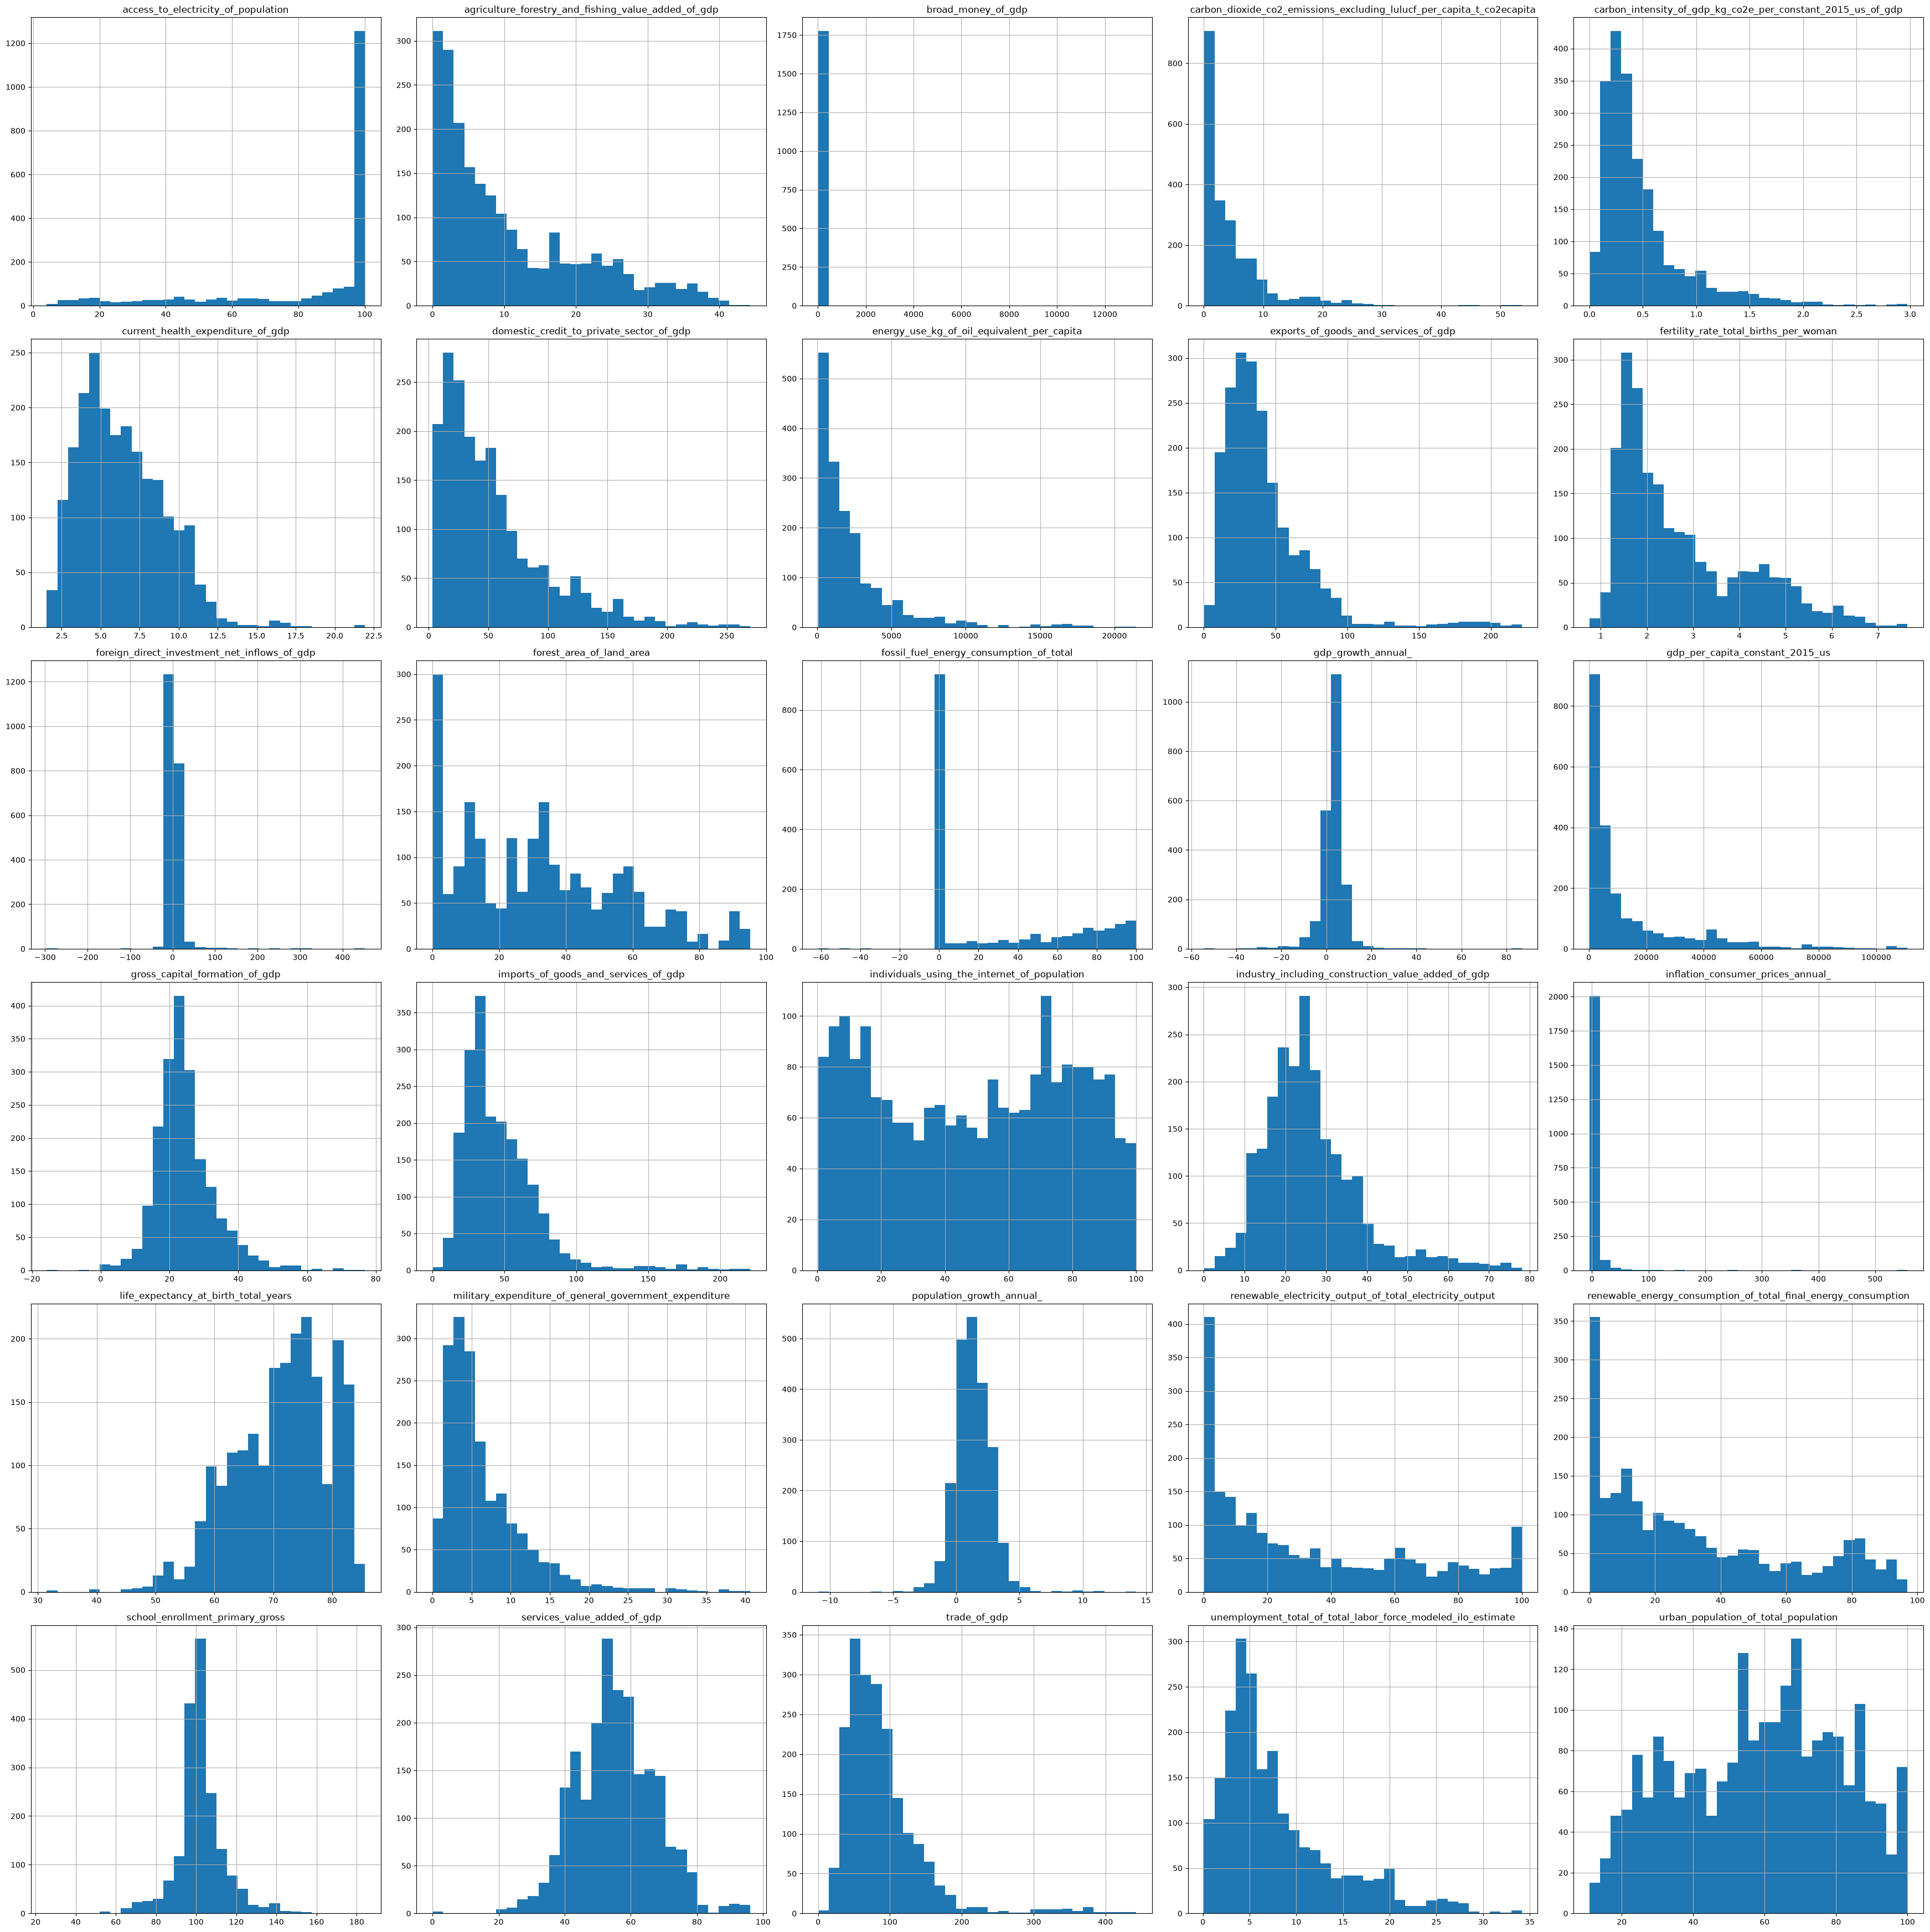

In [211]:
numeric_cols = df_countries.select_dtypes(include="number").columns.drop("year")

df_countries[numeric_cols].hist(
    figsize=(35, 35),
    bins=30
)

plt.tight_layout()
plt.show()

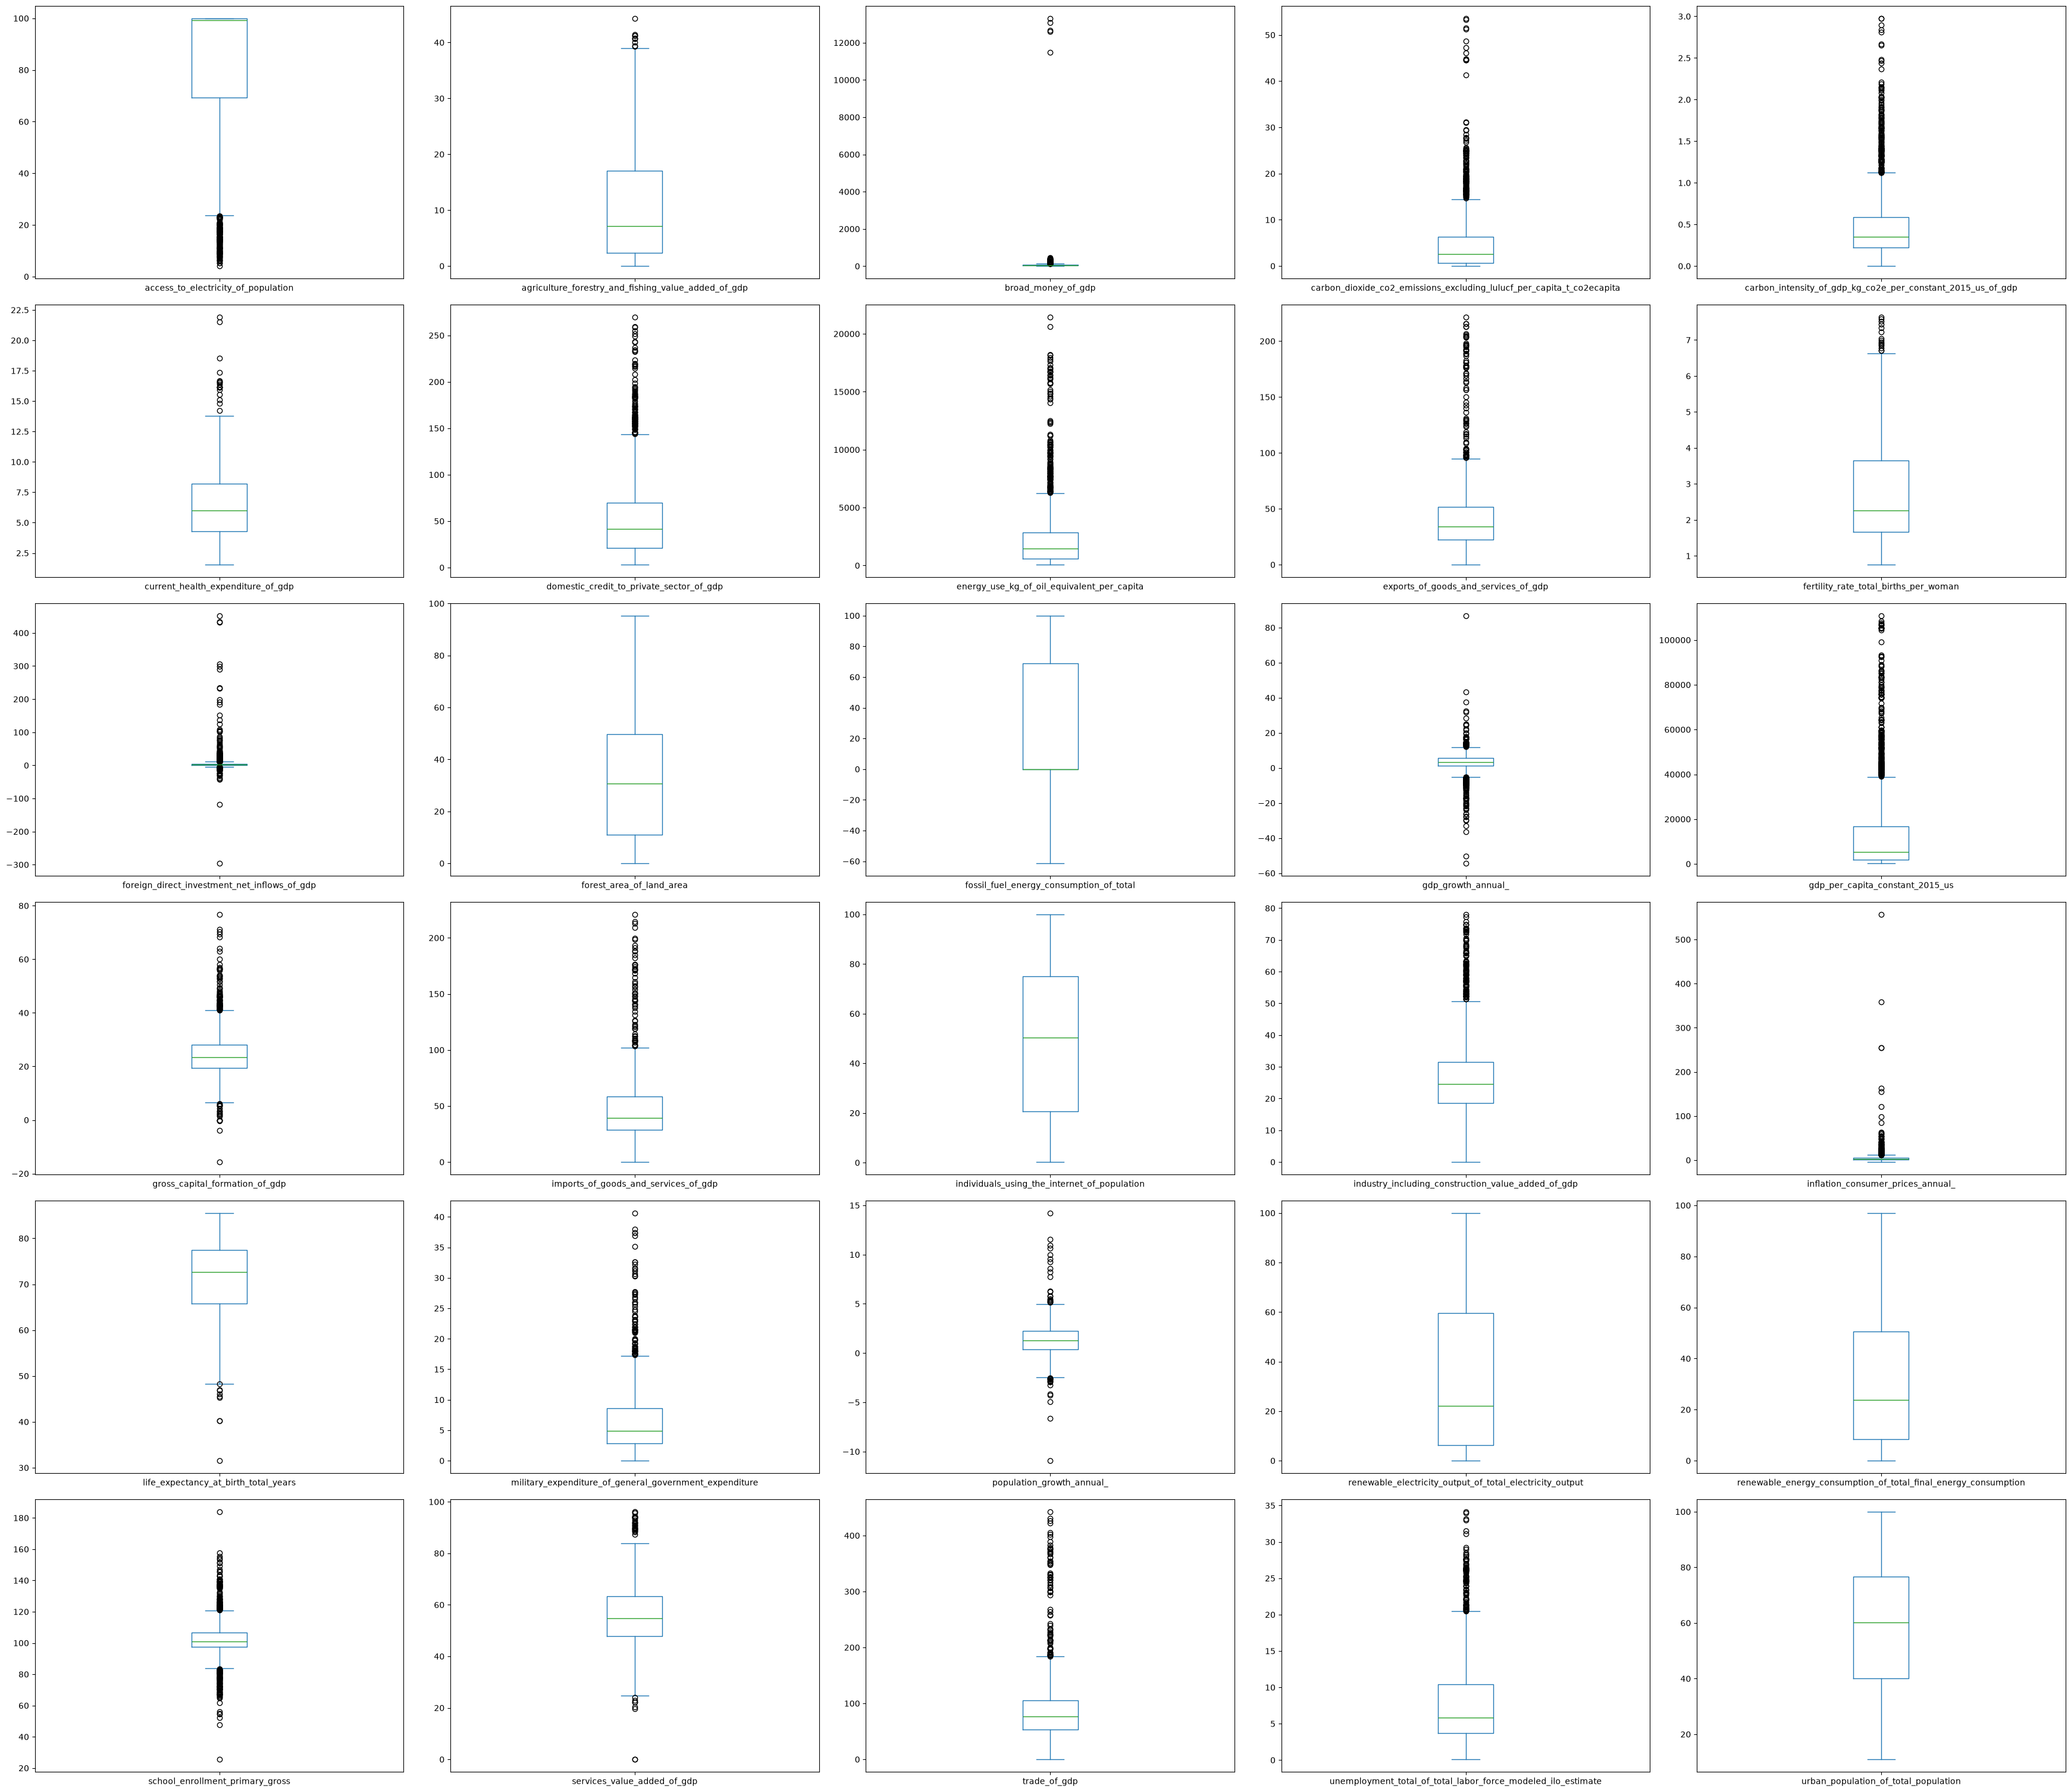

In [212]:
numeric_cols = df_countries.select_dtypes(include="number").columns.drop("year")

df_countries[numeric_cols].plot(
    kind="box",
    subplots=True,
    layout=(7, 5),
    figsize=(35, 35),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()

In [213]:
nan_summary = (
    pd.DataFrame({
        "nan_count": df_countries.isna().sum(),
        "nan_percentage": df_countries.isna().mean()
    })
    .reset_index(names="Series Name")
    .sort_values("nan_percentage", ascending=False)
)

nan_summary.head()

,Series Name,nan_count,nan_percentage
15,fossil_fuel_energy_consumption_of_total,496,0.227106
10,energy_use_kg_of_oil_equivalent_per_capita,456,0.208791
24,military_expenditure_of_general_government_exp...,434,0.198718
5,broad_money_of_gdp,403,0.184524
28,school_enrollment_primary_gross,334,0.152930


In [214]:
negative_counts = df_countries.select_dtypes(include="number").apply(
    lambda col: (col < 0).sum())


negative_counts.sort_values(ascending=False).head(10)

Series Name
gdp_growth_annual_                                                       365
population_growth_annual_                                                315
inflation_consumer_prices_annual_                                        187
foreign_direct_investment_net_inflows_of_gdp                             162
fossil_fuel_energy_consumption_of_total                                    6
gross_capital_formation_of_gdp                                             3
broad_money_of_gdp                                                         0
current_health_expenditure_of_gdp                                          0
carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp                0
carbon_dioxide_co2_emissions_excluding_lulucf_per_capita_t_co2ecapita      0
dtype: int64

In [215]:
df_countries.loc[
    df_countries["fossil_fuel_energy_consumption_of_total"] < 0,
    "fossil_fuel_energy_consumption_of_total"
] = np.nan

df_countries.loc[
    df_countries["gross_capital_formation_of_gdp"] < 0,
    "gross_capital_formation_of_gdp"
] = np.nan

In [216]:
df_countries["trade_openness_ratio"] = (
    df_countries["exports_of_goods_and_services_of_gdp"]
    + df_countries["imports_of_goods_and_services_of_gdp"]
)

comparison = df_countries[
    ["trade_of_gdp", "trade_openness_ratio"]
].copy()

comparison["difference"] = (
    comparison["trade_of_gdp"]
    - comparison["trade_openness_ratio"]
)

comparison.describe()

Series Name,trade_of_gdp,trade_openness_ratio,difference
count,1984.000000,1984.000000,1.984000e+03
mean,88.275220,88.275220,-1.522080e-17
std,55.750341,55.750341,1.099970e-14
min,0.000000,0.000000,-5.684342e-14
25%,53.257715,53.257715,0.000000e+00
50%,76.251541,76.251541,0.000000e+00
75%,105.529920,105.529920,0.000000e+00
max,442.620019,442.620019,5.684342e-14


In [217]:
# as trade_of_gdp == trade_openness_ratio delete the two columns
df_countries = df_countries.drop(columns=['exports_of_goods_and_services_of_gdp', 'imports_of_goods_and_services_of_gdp'])

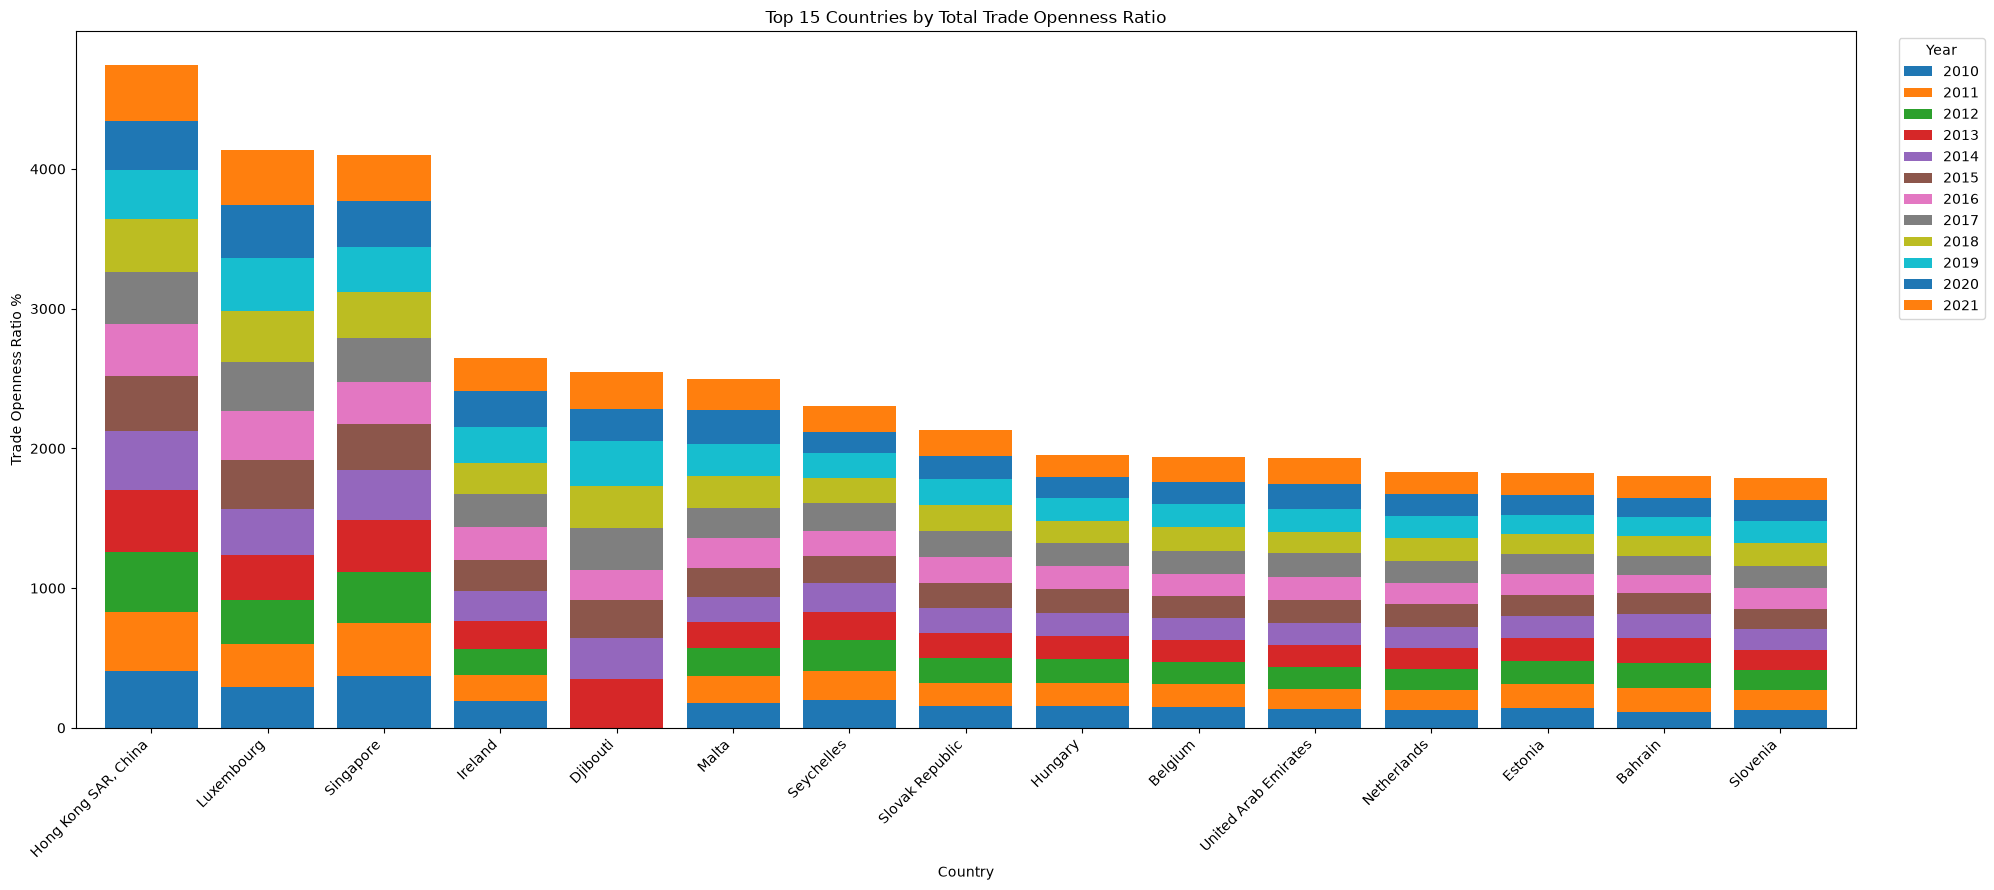

In [218]:
# Get total for ranking
country_totals = (
    df_countries
    .groupby("country_name")["trade_openness_ratio"]
    .sum()
    .sort_values(ascending=False)
)

# Top 15 countries
top_15_countries = country_totals.head(15).index

# Keep only top 15
top_15_df = df_countries[
    df_countries["country_name"].isin(top_15_countries)
].copy()

# Put years into columns
plot_data = top_15_df.pivot(
    index="country_name",
    columns="year",
    values="trade_openness_ratio"
)

# Order countries by their total
plot_data = plot_data.loc[top_15_countries]

# Stacked bar plot
ax = plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(20, 9),
    width=0.8
)

plt.title("Top 15 Countries by Total Trade Openness Ratio")
plt.xlabel("Country")
plt.ylabel("Trade Openness Ratio %")

plt.xticks(rotation=45, ha="right")
plt.legend(
    title="Year",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

C:\Users\minam\AppData\Local\Temp\ipykernel_22444\1383808293.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(
C:\Users\minam\AppData\Local\Temp\ipykernel_22444\1383808293.py:45: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(


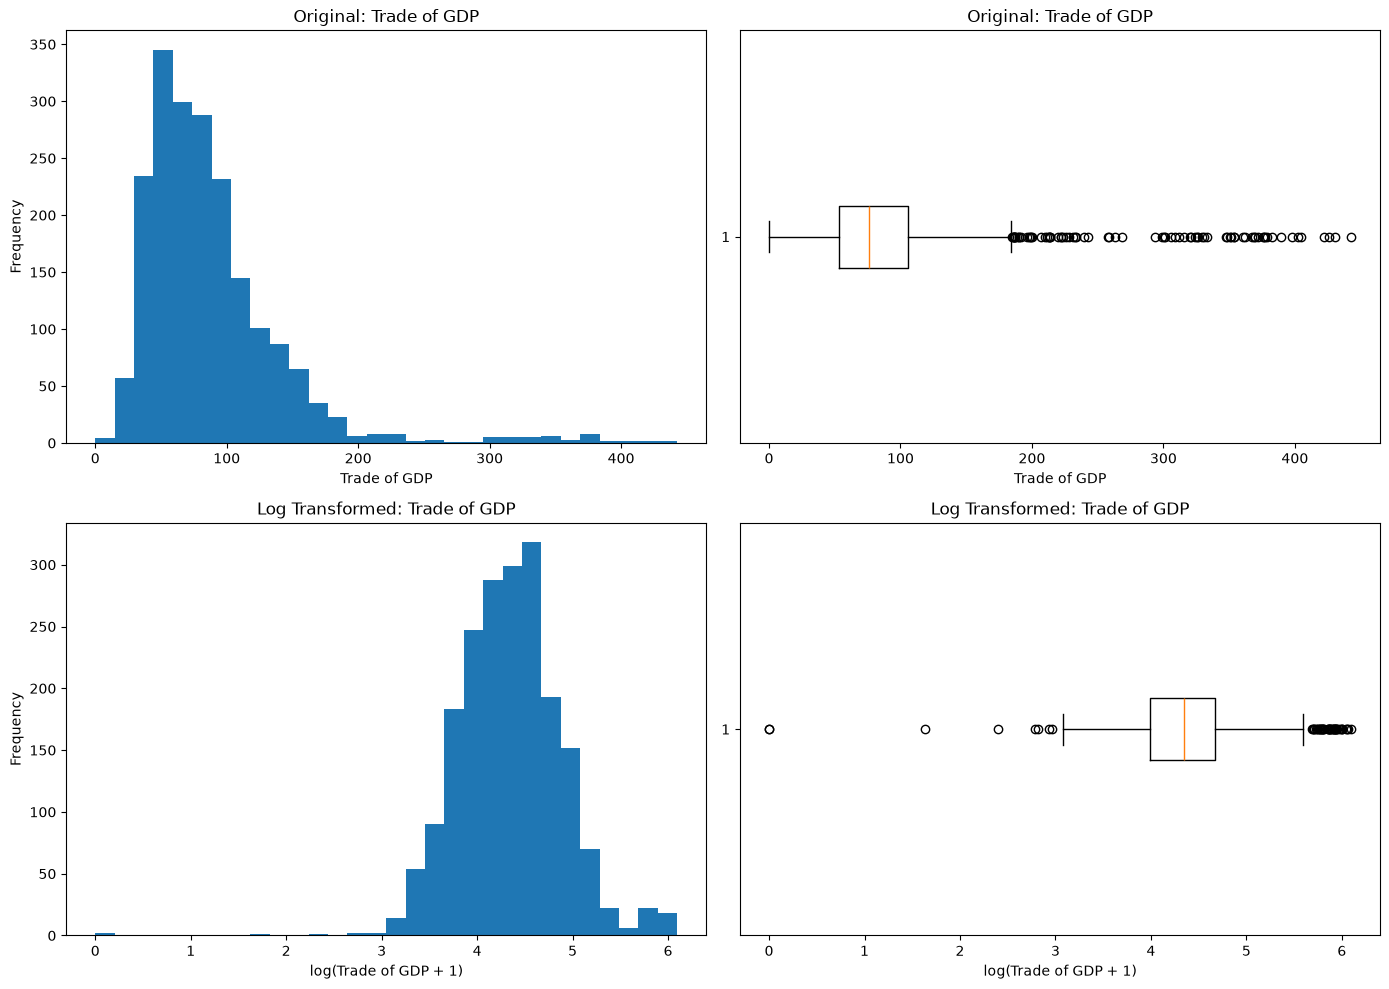

In [219]:
import numpy as np
import matplotlib.pyplot as plt

# Log transformation
df_countries['trade_of_gdp_log'] = np.log1p(df_countries['trade_of_gdp'])

# Create 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -------------------------
# Original: Histogram
# -------------------------
axes[0, 0].hist(
    df_countries['trade_of_gdp'].dropna(),
    bins=30
)
axes[0, 0].set_title('Original: Trade of GDP')
axes[0, 0].set_xlabel('Trade of GDP')
axes[0, 0].set_ylabel('Frequency')

# -------------------------
# Original: Boxplot
# -------------------------
axes[0, 1].boxplot(
    df_countries['trade_of_gdp'].dropna(),
    vert=False
)
axes[0, 1].set_title('Original: Trade of GDP')
axes[0, 1].set_xlabel('Trade of GDP')

# -------------------------
# Log: Histogram
# -------------------------
axes[1, 0].hist(
    df_countries['trade_of_gdp_log'].dropna(),
    bins=30
)
axes[1, 0].set_title('Log Transformed: Trade of GDP')
axes[1, 0].set_xlabel('log(Trade of GDP + 1)')
axes[1, 0].set_ylabel('Frequency')

# -------------------------
# Log: Boxplot
# -------------------------
axes[1, 1].boxplot(
    df_countries['trade_of_gdp_log'].dropna(),
    vert=False
)
axes[1, 1].set_title('Log Transformed: Trade of GDP')
axes[1, 1].set_xlabel('log(Trade of GDP + 1)')

plt.tight_layout()
plt.show()

In [220]:
df_countries.drop(columns=['trade_of_gdp', 'trade_openness_ratio'], inplace=True)

In [221]:
index_components = [
    "access_to_electricity_of_population",
    "individuals_using_the_internet_of_population",
    "life_expectancy_at_birth_total_years",
    "urban_population_of_total_population"
]

missing_components = (
    df_countries[index_components]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_components

Series Name
individuals_using_the_internet_of_population    2.289377
access_to_electricity_of_population             0.000000
life_expectancy_at_birth_total_years            0.000000
urban_population_of_total_population            0.000000
dtype: float64

In [222]:
df_countries["individuals_using_the_internet_of_population"] = (df_countries["individuals_using_the_internet_of_population"].fillna(df_countries.groupby("country_code")["individuals_using_the_internet_of_population"].transform("mean")))

In [223]:
missing_components = (
    df_countries[index_components]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
missing_components

Series Name
access_to_electricity_of_population             0.0
individuals_using_the_internet_of_population    0.0
life_expectancy_at_birth_total_years            0.0
urban_population_of_total_population            0.0
dtype: float64

In [224]:
internet_col = "individuals_using_the_internet_of_population"

remaining = df_countries[
    df_countries[internet_col].isna()
]

print(
    remaining[
        ["country_code", "country_name", "year"]
    ]
)

Empty DataFrame
Columns: [country_code, country_name, year]
Index: []


In [225]:
df_countries["individuals_using_the_internet_of_population"] = df_countries["individuals_using_the_internet_of_population"].fillna(value=df_countries["individuals_using_the_internet_of_population"].mean())

In [226]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_countries[
    [f"{col}_z" for col in index_components]
] = scaler.fit_transform(
    df_countries[index_components]
)

df_countries["Socioeconomic_developmen_Index"] = (
    df_countries[[f"{col}_z" for col in index_components]]
    .mean(axis=1)
)

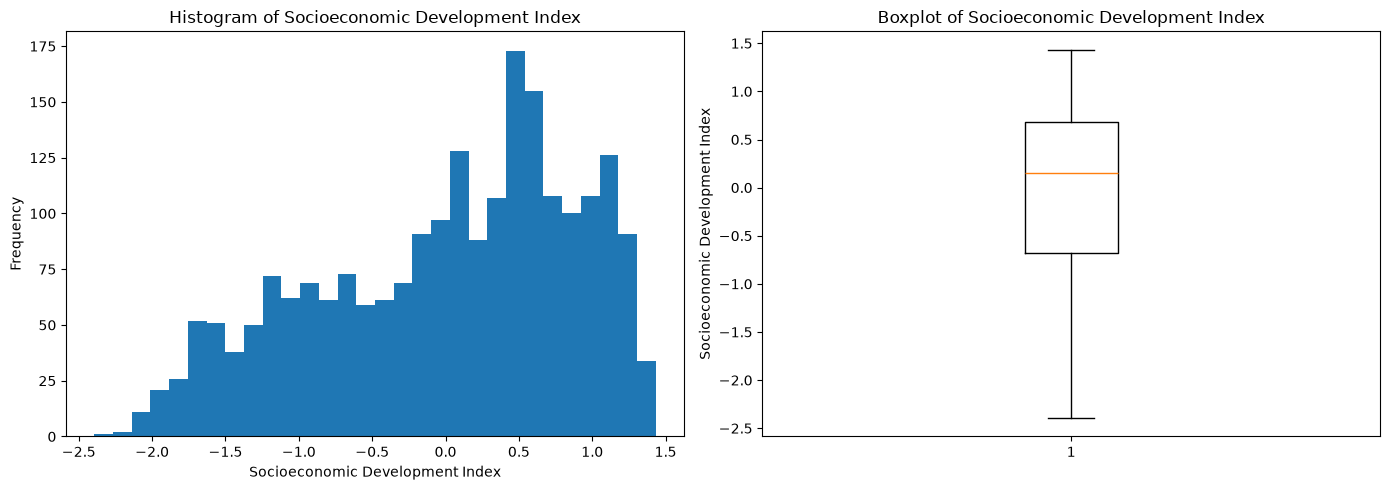

In [227]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(
    df_countries["Socioeconomic_developmen_Index"].dropna(),
    bins=30
)
axes[0].set_xlabel("Socioeconomic Development Index")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Histogram of Socioeconomic Development Index")

# Boxplot
axes[1].boxplot(
    df_countries["Socioeconomic_developmen_Index"].dropna()
)
axes[1].set_ylabel("Socioeconomic Development Index")
axes[1].set_title("Boxplot of Socioeconomic Development Index")

plt.tight_layout()
plt.show()

In [228]:
df_countries.drop(columns=[
    "access_to_electricity_of_population",
    "individuals_using_the_internet_of_population",
    "life_expectancy_at_birth_total_years",
    "urban_population_of_total_population"
], inplace=True)

In [229]:
from sklearn.preprocessing import StandardScaler

energy_cols = [
    "energy_use_kg_of_oil_equivalent_per_capita",
    "carbon_dioxide_co2_emissions_excluding_lulucf_per_capita_t_co2ecapita"
]

# 1. Apply log transformation directly on raw, positive data
#    (Using log1p handles 0 values safely)
df_log = np.log1p(df_countries[energy_cols])

# 2. Standardize the log-transformed variables
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_log)
df_scaled = pd.DataFrame(scaled_array, columns=energy_cols, index=df_countries.index)

# 3. Create composite index handling missing values row-wise
df_countries["Energy_Environmental_Index"] = df_scaled.mean(axis=1, skipna=True)

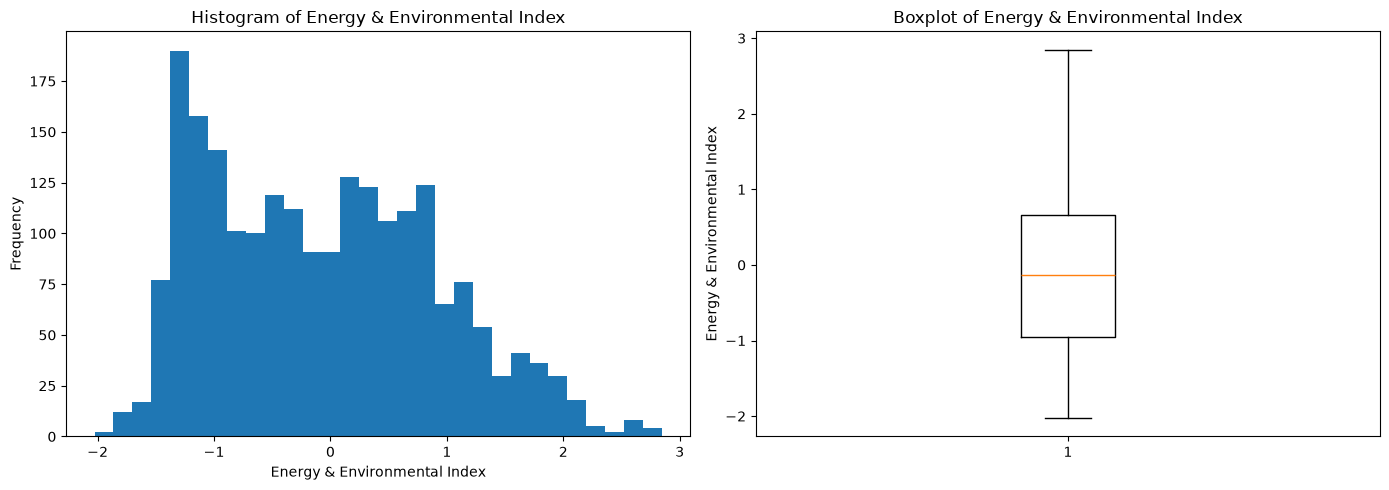

In [230]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Remove NaN values
index_data = df_countries["Energy_Environmental_Index"].dropna()

# Histogram
axes[0].hist(index_data, bins=30)
axes[0].set_xlabel("Energy & Environmental Index")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Histogram of Energy & Environmental Index")

# Boxplot
axes[1].boxplot(index_data)
axes[1].set_ylabel("Energy & Environmental Index")
axes[1].set_title("Boxplot of Energy & Environmental Index")

plt.tight_layout()
plt.show()

In [231]:
df_countries.drop(columns=energy_cols, inplace=True)

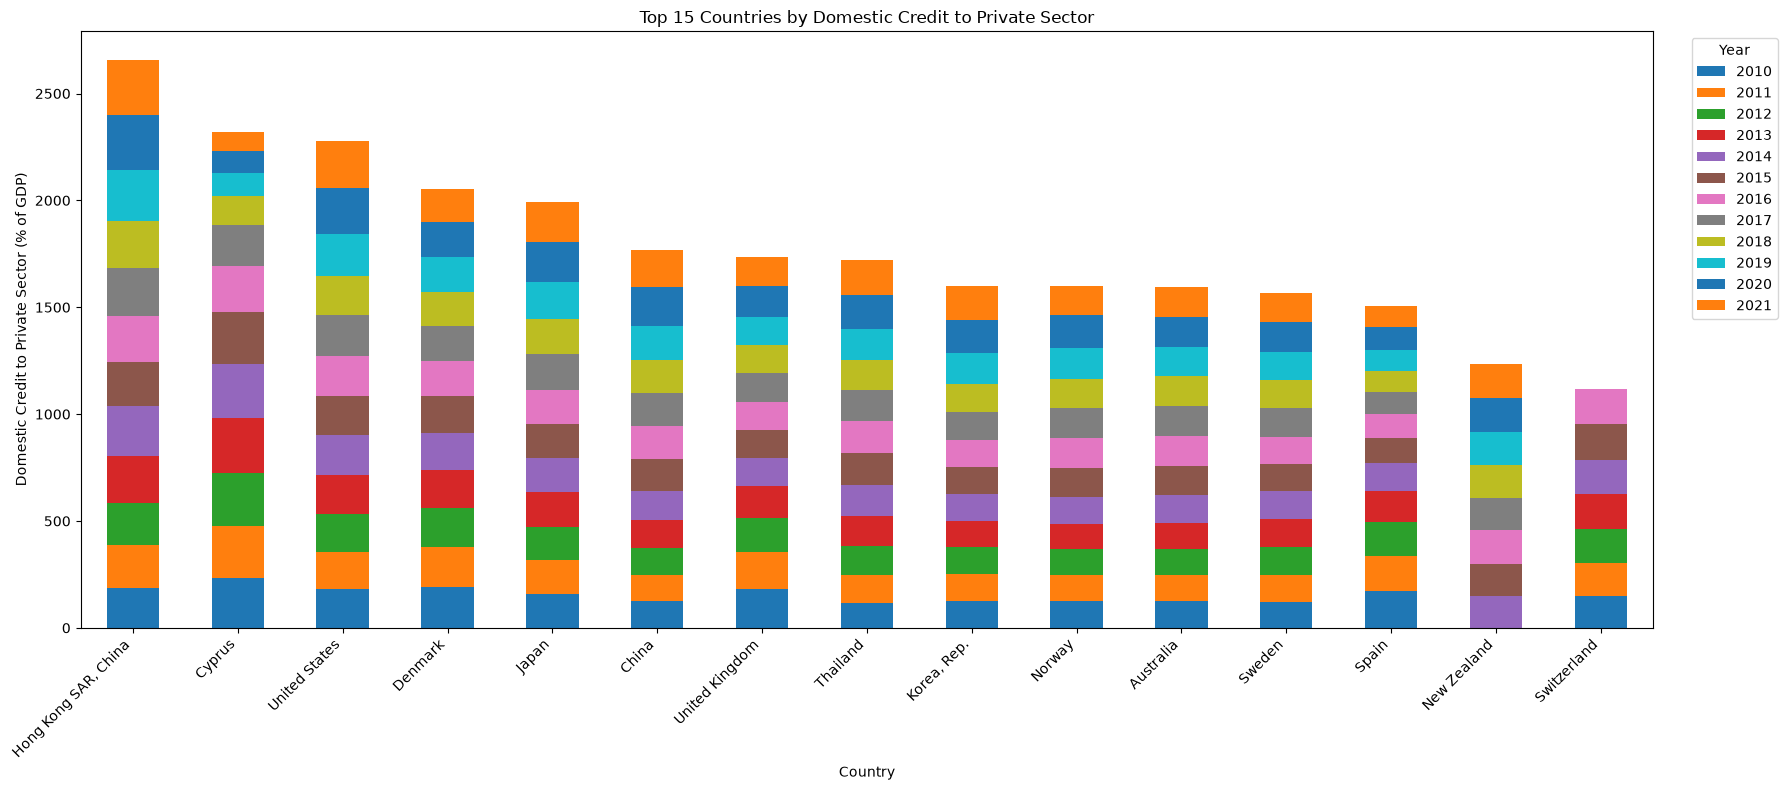

In [232]:
feature = "domestic_credit_to_private_sector_of_gdp"

# 1. Find the top 15 countries based on their average value
top_15_countries = (
    df_countries
    .groupby("country_name")[feature]
    .mean()
    .nlargest(15)
    .index
)

# 2. Keep only those countries
top_15 = df_countries[
    df_countries["country_name"].isin(top_15_countries)
]

# 3. Put years as columns
plot_data = top_15.pivot_table(
    index="country_name",
    columns="year",
    values=feature,
    aggfunc="mean"
)

# 4. Sort countries by their overall sum
plot_data = plot_data.loc[
    plot_data.sum(axis=1).sort_values(ascending=False).index
]

# 5. Plot
ax = plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(18, 8)
)

plt.xlabel("Country")
plt.ylabel("Domestic Credit to Private Sector (% of GDP)")
plt.title("Top 15 Countries by Domestic Credit to Private Sector")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [233]:
df_countries['domestic_credit_to_private_sector_of_gdp_log'] = np.log1p(df_countries['domestic_credit_to_private_sector_of_gdp'])

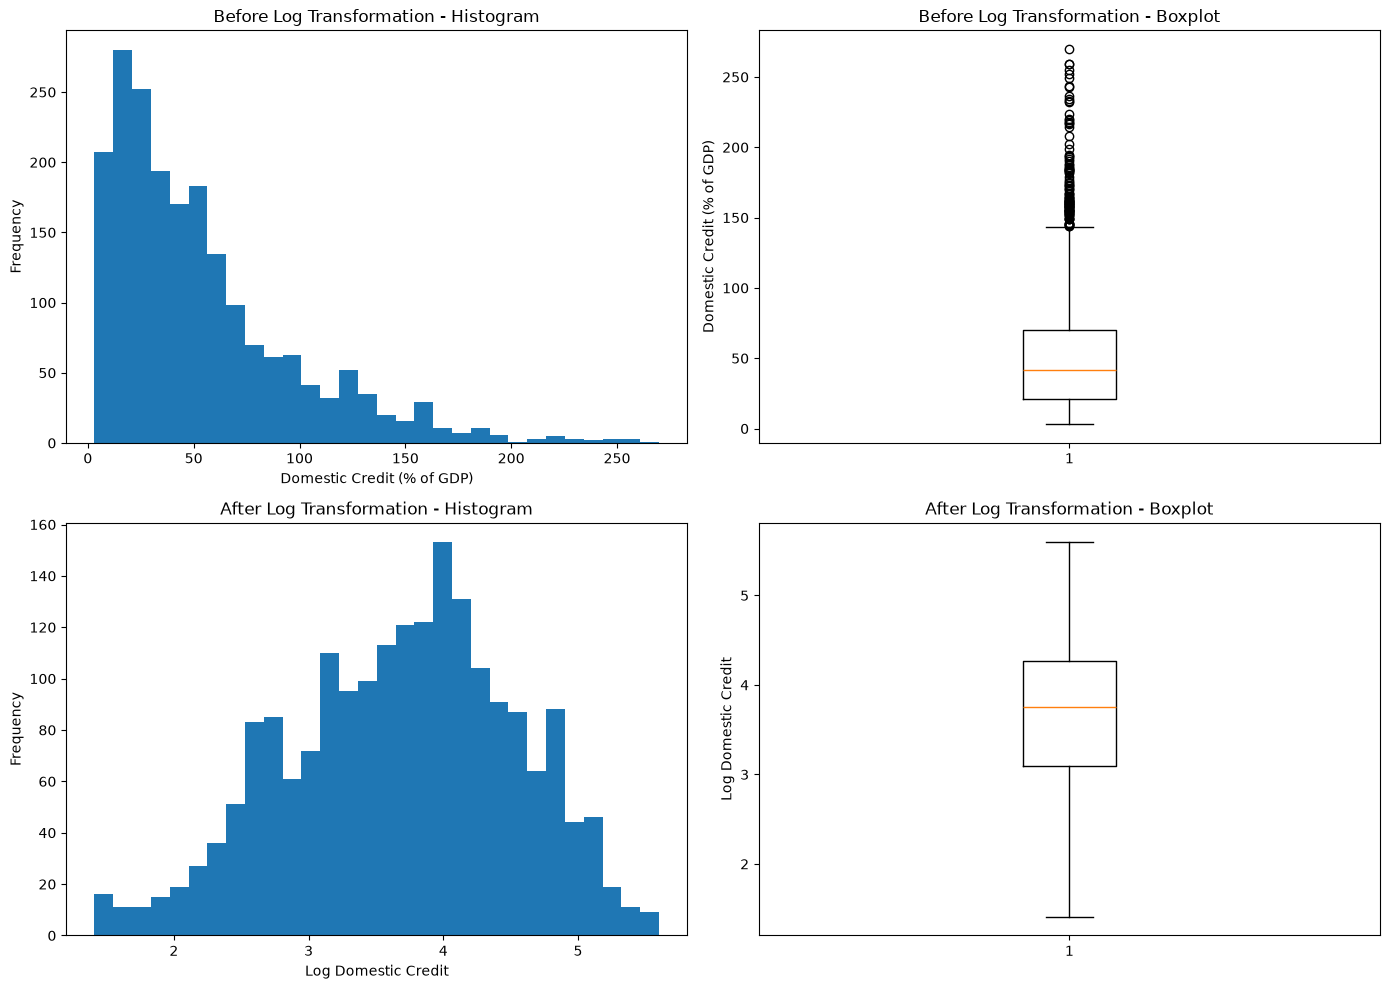

In [234]:
original = df_countries["domestic_credit_to_private_sector_of_gdp"].dropna()
logged = df_countries["domestic_credit_to_private_sector_of_gdp_log"].dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---------------- BEFORE ----------------

# Histogram
axes[0, 0].hist(original, bins=30)
axes[0, 0].set_title("Before Log Transformation - Histogram")
axes[0, 0].set_xlabel("Domestic Credit (% of GDP)")
axes[0, 0].set_ylabel("Frequency")

# Boxplot
axes[0, 1].boxplot(original)
axes[0, 1].set_title("Before Log Transformation - Boxplot")
axes[0, 1].set_ylabel("Domestic Credit (% of GDP)")


# ---------------- AFTER ----------------

# Histogram
axes[1, 0].hist(logged, bins=30)
axes[1, 0].set_title("After Log Transformation - Histogram")
axes[1, 0].set_xlabel("Log Domestic Credit")
axes[1, 0].set_ylabel("Frequency")

# Boxplot
axes[1, 1].boxplot(logged)
axes[1, 1].set_title("After Log Transformation - Boxplot")
axes[1, 1].set_ylabel("Log Domestic Credit")

plt.tight_layout()
plt.show()

In [235]:
df_countries.drop(columns= 'domestic_credit_to_private_sector_of_gdp', inplace=True)

In [236]:
df_countries['foreign_direct_investment_net_inflows_of_gdp'].describe()

count    2139.000000
mean        5.971016
std        25.307740
min      -296.013333
25%         1.168310
50%         2.719823
75%         5.068896
max       452.220863
Name: foreign_direct_investment_net_inflows_of_gdp, dtype: float64

In [237]:
fdi = df_countries[
    ['country_name', 'year', 'foreign_direct_investment_net_inflows_of_gdp']
].dropna()

top_15 = fdi.sort_values(
    by='foreign_direct_investment_net_inflows_of_gdp',
    ascending=False
).head(15)

bottom_15 = fdi.sort_values(
    by='foreign_direct_investment_net_inflows_of_gdp',
    ascending=True
).head(15)

print("TOP 15:")
display(top_15)

print("BOTTOM 15:")
display(bottom_15)

TOP 15:


Series Name,country_name,year,foreign_direct_investment_net_inflows_of_gdp
1832,Malta,2018,452.220863
1835,Malta,2021,433.606840
681,Cyprus,2019,431.788576
680,Cyprus,2018,307.086610
1831,Malta,2017,299.824774
674,Cyprus,2012,289.858156
1749,Luxembourg,2019,234.310617
676,Cyprus,2014,233.165814
1833,Malta,2019,198.199647
1834,Malta,2020,191.921868


BOTTOM 15:


Series Name,country_name,year,foreign_direct_investment_net_inflows_of_gdp
682,Cyprus,2020,-296.013333
1748,Luxembourg,2018,-117.233948
1747,Luxembourg,2017,-41.650995
1244,Hungary,2018,-40.108246
1974,Mongolia,2016,-37.172653
2818,Switzerland,2020,-31.552045
2072,Netherlands,2018,-30.657677
1315,Iceland,2017,-27.932437
1762,"Macao SAR, China",2020,-24.578008
2074,Netherlands,2020,-23.686012


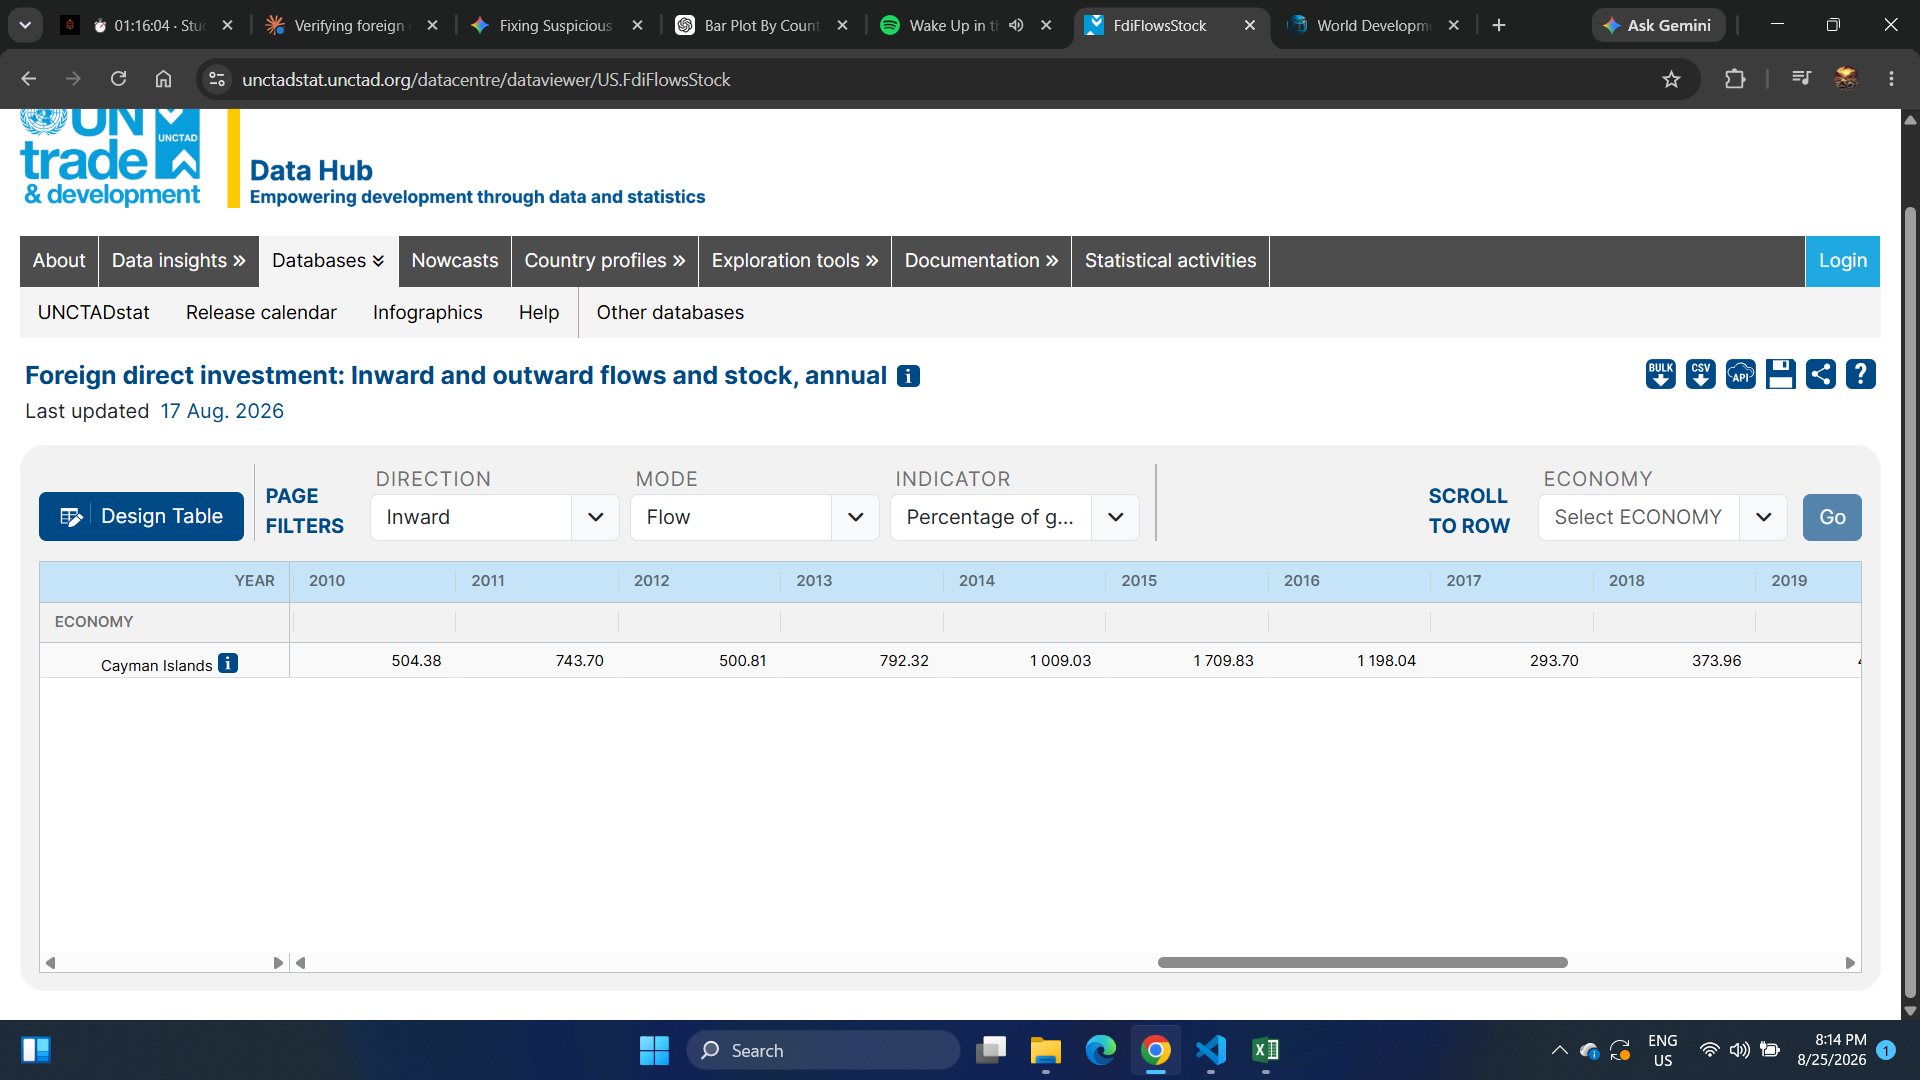

In [238]:
from IPython.display import Image
Image(filename=r"D:\Projects\2B_Data_Science_Portfolio\outputs\validate_FDI.png", width=400)

In [239]:
fdi = df_countries['foreign_direct_investment_net_inflows_of_gdp']

df_countries['fdi_log'] = np.sign(fdi) * np.log1p(np.abs(fdi))

C:\Users\minam\AppData\Local\Temp\ipykernel_22444\1836273093.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 0].boxplot(fdi.dropna(), vert=False)
C:\Users\minam\AppData\Local\Temp\ipykernel_22444\1836273093.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(df_countries['fdi_log'].dropna(), vert=False)


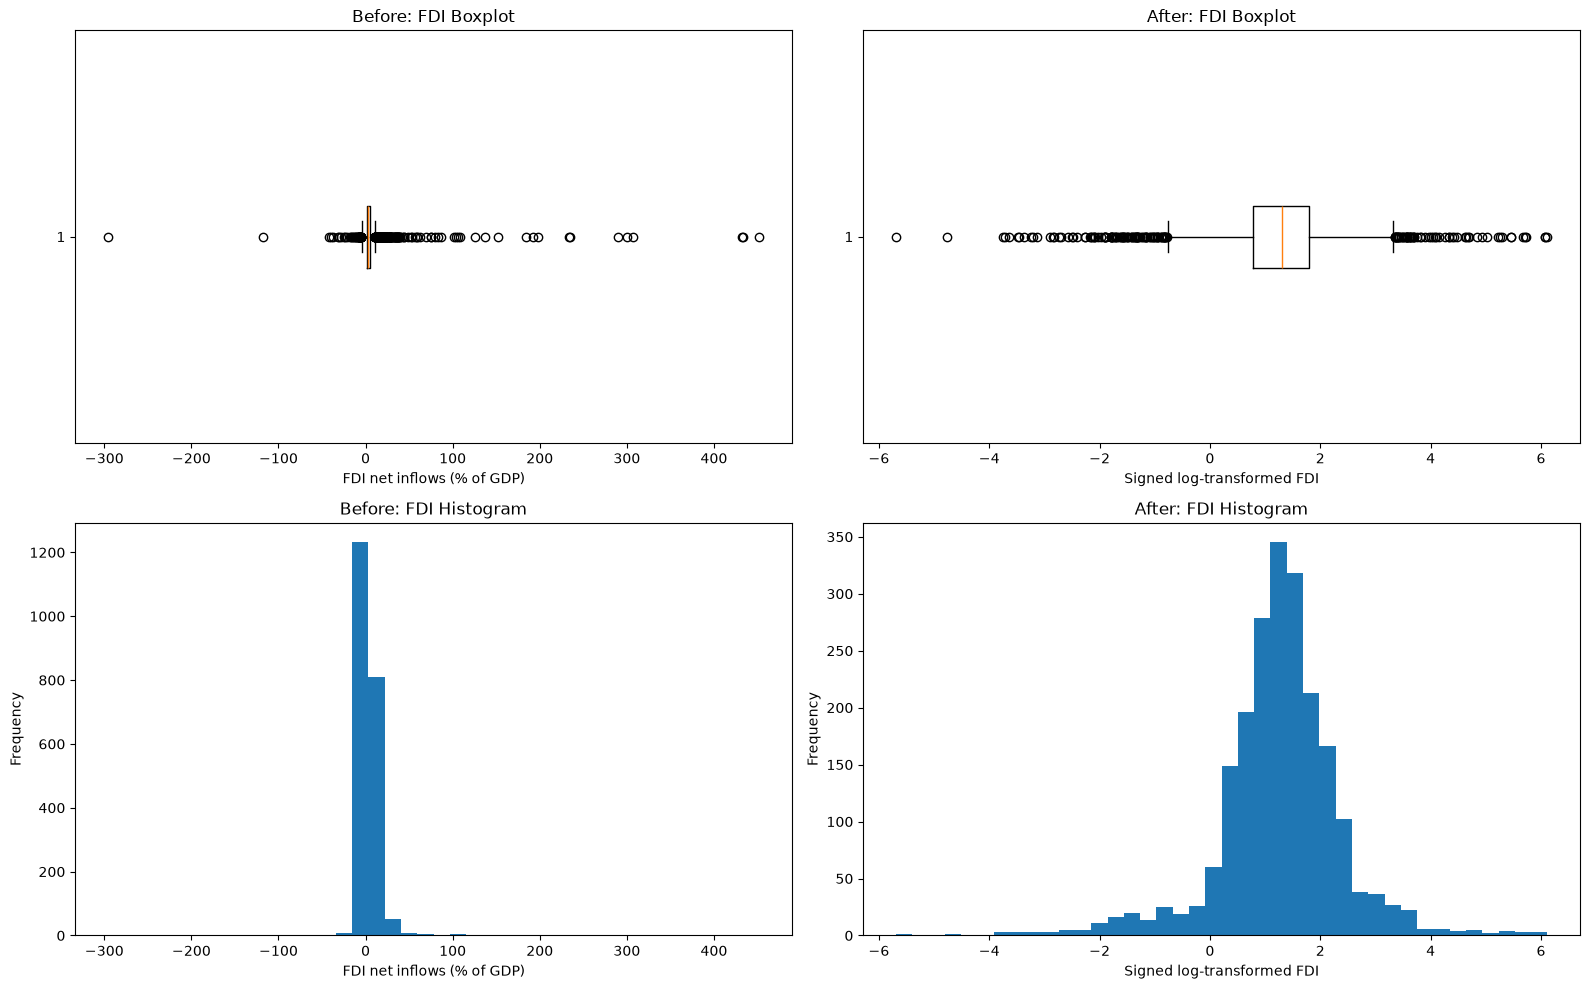

In [240]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Before boxplot
axes[0, 0].boxplot(fdi.dropna(), vert=False)
axes[0, 0].set_title('Before: FDI Boxplot')
axes[0, 0].set_xlabel('FDI net inflows (% of GDP)')

# After boxplot
axes[0, 1].boxplot(df_countries['fdi_log'].dropna(), vert=False)
axes[0, 1].set_title('After: FDI Boxplot')
axes[0, 1].set_xlabel('Signed log-transformed FDI')

# Before histogram
axes[1, 0].hist(fdi.dropna(), bins=40)
axes[1, 0].set_title('Before: FDI Histogram')
axes[1, 0].set_xlabel('FDI net inflows (% of GDP)')
axes[1, 0].set_ylabel('Frequency')

# After histogram
axes[1, 1].hist(df_countries['fdi_log'].dropna(), bins=40)
axes[1, 1].set_title('After: FDI Histogram')
axes[1, 1].set_xlabel('Signed log-transformed FDI')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [241]:
df_countries.drop(columns='foreign_direct_investment_net_inflows_of_gdp', inplace=True)

In [242]:
print("top 15 (inflation_consumer_prices_annual_)")
display(df_countries[['country_name', 'year', 'inflation_consumer_prices_annual_']].sort_values(ascending=False, by='inflation_consumer_prices_annual_').head(15))
print("tail 15 (inflation_consumer_prices_annual_)")
display(df_countries[['country_name', 'year', 'inflation_consumer_prices_annual_']].sort_values(ascending=True, by='inflation_consumer_prices_annual_').head(15))

top 15 (inflation_consumer_prices_annual_)


Series Name,country_name,year,inflation_consumer_prices_annual_
3178,Zimbabwe,2020,557.201817
2783,Sudan,2021,359.093041
3177,Zimbabwe,2019,255.304991
3090,"Venezuela, RB",2016,254.948535
2782,Sudan,2020,163.257782
1643,Lebanon,2021,154.756096
3089,"Venezuela, RB",2015,121.738085
3179,Zimbabwe,2021,98.546105
1642,Lebanon,2020,84.864333
2780,Sudan,2018,63.292507


tail 15 (inflation_consumer_prices_annual_)


Series Name,country_name,year,inflation_consumer_prices_annual_
579,Comoros,2013,-4.294873
1476,Kiribati,2010,-3.899550
1637,Lebanon,2015,-3.749145
405,Burkina Faso,2019,-3.233389
2706,St. Lucia,2016,-3.078218
1478,Kiribati,2012,-3.045863
416,Burundi,2018,-2.814698
2398,Qatar,2020,-2.540315
2121,Niger,2019,-2.489793
3173,Zimbabwe,2015,-2.430968


In [243]:
inflation = df_countries['inflation_consumer_prices_annual_']

df_countries['inflation_log'] = (np.sign(inflation)* np.log1p(np.abs(inflation)))

C:\Users\minam\AppData\Local\Temp\ipykernel_22444\456336597.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 0].boxplot(
C:\Users\minam\AppData\Local\Temp\ipykernel_22444\456336597.py:45: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(


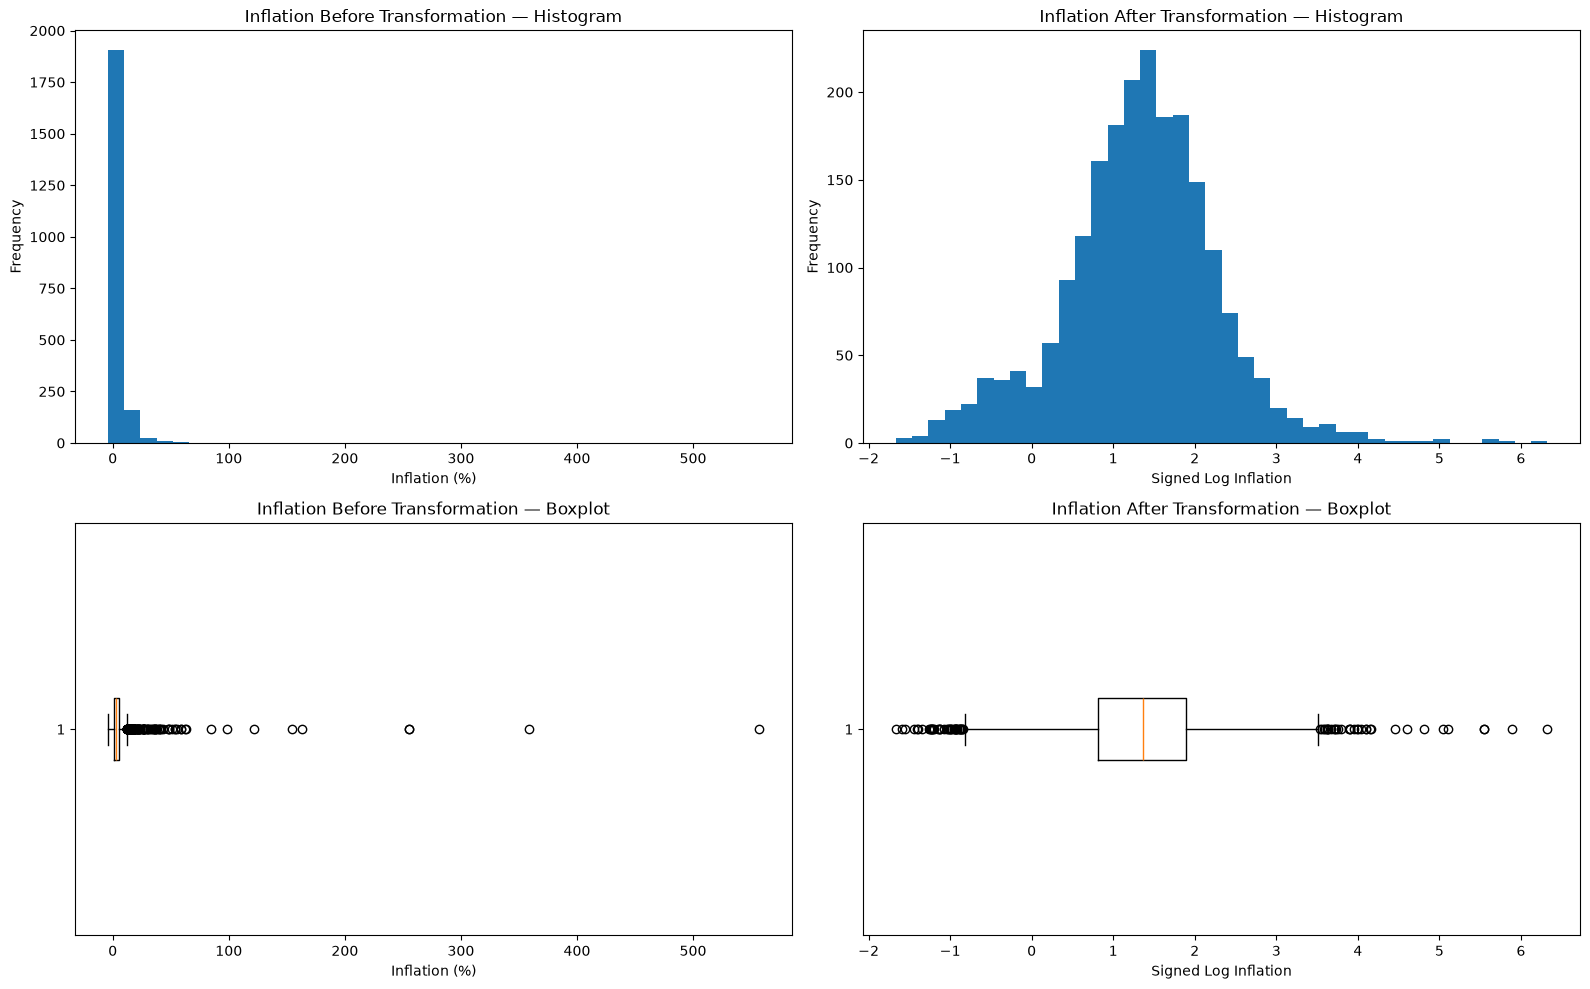

In [244]:
inflation = df_countries['inflation_consumer_prices_annual_']

df_countries['inflation_log'] = (
    np.sign(inflation)
    * np.log1p(np.abs(inflation))
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# -------------------------
# BEFORE — Histogram
# -------------------------
axes[0, 0].hist(
    inflation.dropna(),
    bins=40
)
axes[0, 0].set_title('Inflation Before Transformation — Histogram')
axes[0, 0].set_xlabel('Inflation (%)')
axes[0, 0].set_ylabel('Frequency')

# -------------------------
# AFTER — Histogram
# -------------------------
axes[0, 1].hist(
    df_countries['inflation_log'].dropna(),
    bins=40
)
axes[0, 1].set_title('Inflation After Transformation — Histogram')
axes[0, 1].set_xlabel('Signed Log Inflation')
axes[0, 1].set_ylabel('Frequency')

# -------------------------
# BEFORE — Boxplot
# -------------------------
axes[1, 0].boxplot(
    inflation.dropna(),
    vert=False
)
axes[1, 0].set_title('Inflation Before Transformation — Boxplot')
axes[1, 0].set_xlabel('Inflation (%)')

# -------------------------
# AFTER — Boxplot
# -------------------------
axes[1, 1].boxplot(
    df_countries['inflation_log'].dropna(),
    vert=False
)
axes[1, 1].set_title('Inflation After Transformation — Boxplot')
axes[1, 1].set_xlabel('Signed Log Inflation')

plt.tight_layout()
plt.show()

In [245]:
df_countries.drop(columns='inflation_consumer_prices_annual_', inplace=True)

In [246]:
df_countries['broad_money_of_gdp'].describe()

count     1781.000000
mean        96.605770
std        667.318131
min          8.585482
25%         33.251200
50%         51.223294
75%         74.574585
max      13309.489839
Name: broad_money_of_gdp, dtype: float64

In [247]:
print("top 15 (broad_money_of_gdp)")
display(df_countries[['country_name', 'year', 'broad_money_of_gdp']].sort_values(ascending=False, by='broad_money_of_gdp').head(15))
print("tail 15 (broad_money_of_gdp)")
display(df_countries[['country_name', 'year', 'broad_money_of_gdp']].sort_values(ascending=True, by='broad_money_of_gdp').head(15))

top 15 (broad_money_of_gdp)


Series Name,country_name,year,broad_money_of_gdp
2524,Sierra Leone,2014,13309.489839
2521,Sierra Leone,2011,13083.807851
2522,Sierra Leone,2012,12648.743488
2520,Sierra Leone,2010,12585.001367
2523,Sierra Leone,2013,11490.058379
1234,"Hong Kong SAR, China",2020,454.703219
1235,"Hong Kong SAR, China",2021,437.798214
1233,"Hong Kong SAR, China",2019,403.314069
1231,"Hong Kong SAR, China",2017,396.151789
1232,"Hong Kong SAR, China",2018,386.098766


tail 15 (broad_money_of_gdp)


Series Name,country_name,year,broad_money_of_gdp
518,Chad,2012,8.585482
516,Chad,2010,8.701410
517,Chad,2011,8.792249
829,Equatorial Guinea,2011,9.021703
588,"Congo, Dem. Rep.",2010,9.029410
519,Chad,2013,9.657112
589,"Congo, Dem. Rep.",2011,9.894900
3178,Zimbabwe,2020,10.002460
3179,Zimbabwe,2021,10.239997
590,"Congo, Dem. Rep.",2012,10.491092


In [248]:
df_countries['broad_money_of_gdp_log'] = np.log1p(df_countries['broad_money_of_gdp'])

C:\Users\minam\AppData\Local\Temp\ipykernel_22444\4071922404.py:34: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 0].boxplot(
C:\Users\minam\AppData\Local\Temp\ipykernel_22444\4071922404.py:44: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(


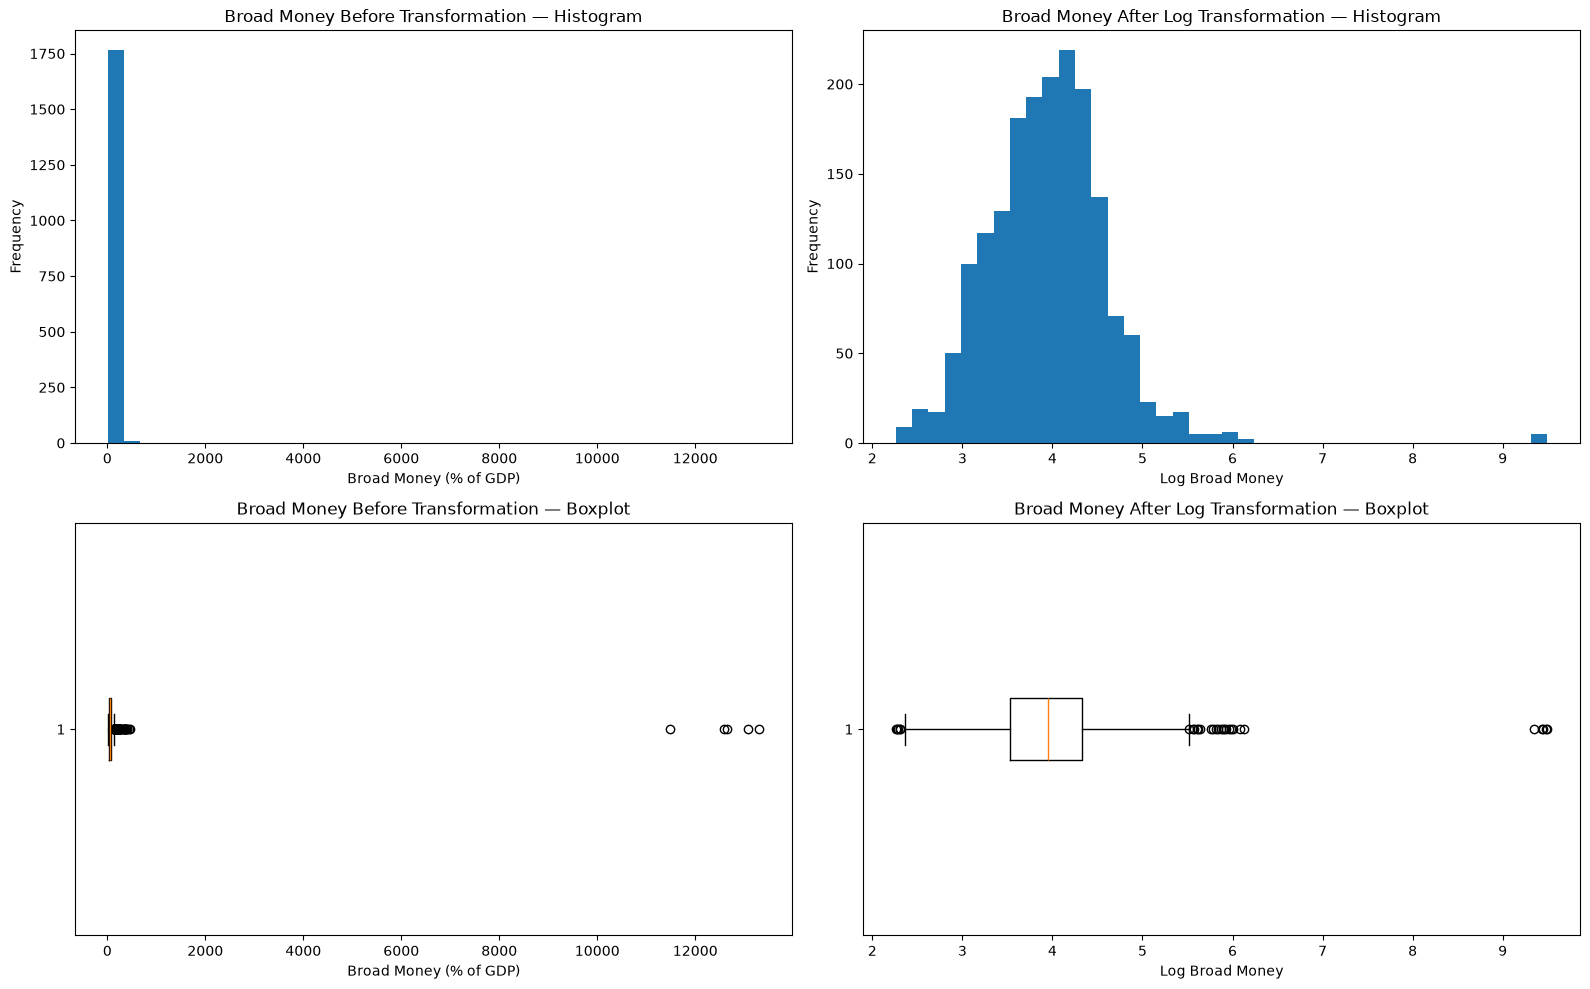

In [249]:
broad_money = df_countries['broad_money_of_gdp']

# Log transformation
df_countries['broad_money_of_gdp_log'] = np.log1p(broad_money)

# Create 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# -------------------------
# BEFORE — Histogram
# -------------------------
axes[0, 0].hist(
    broad_money.dropna(),
    bins=40
)
axes[0, 0].set_title('Broad Money Before Transformation — Histogram')
axes[0, 0].set_xlabel('Broad Money (% of GDP)')
axes[0, 0].set_ylabel('Frequency')

# -------------------------
# AFTER — Histogram
# -------------------------
axes[0, 1].hist(
    df_countries['broad_money_of_gdp_log'].dropna(),
    bins=40
)
axes[0, 1].set_title('Broad Money After Log Transformation — Histogram')
axes[0, 1].set_xlabel('Log Broad Money')
axes[0, 1].set_ylabel('Frequency')

# -------------------------
# BEFORE — Boxplot
# -------------------------
axes[1, 0].boxplot(
    broad_money.dropna(),
    vert=False
)
axes[1, 0].set_title('Broad Money Before Transformation — Boxplot')
axes[1, 0].set_xlabel('Broad Money (% of GDP)')

# -------------------------
# AFTER — Boxplot
# -------------------------
axes[1, 1].boxplot(
    df_countries['broad_money_of_gdp_log'].dropna(),
    vert=False
)
axes[1, 1].set_title('Broad Money After Log Transformation — Boxplot')
axes[1, 1].set_xlabel('Log Broad Money')

plt.tight_layout()
plt.show()

In [250]:
df_countries[
    ['broad_money_of_gdp', 'broad_money_of_gdp_log']
].describe()

Series Name,broad_money_of_gdp,broad_money_of_gdp_log
count,1781.000000,1781.000000
mean,96.605770,3.953415
std,667.318131,0.674641
min,8.585482,2.260250
25%,33.251200,3.533722
50%,51.223294,3.955529
75%,74.574585,4.325120
max,13309.489839,9.496308


In [251]:
df_countries.drop(columns='broad_money_of_gdp', inplace=True)

In [252]:
df_countries['gdp_per_capita_constant_2015_us_log'] = np.log1p(df_countries['gdp_per_capita_constant_2015_us'])

C:\Users\minam\AppData\Local\Temp\ipykernel_22444\1877827544.py:33: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 0].boxplot(
C:\Users\minam\AppData\Local\Temp\ipykernel_22444\1877827544.py:43: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(


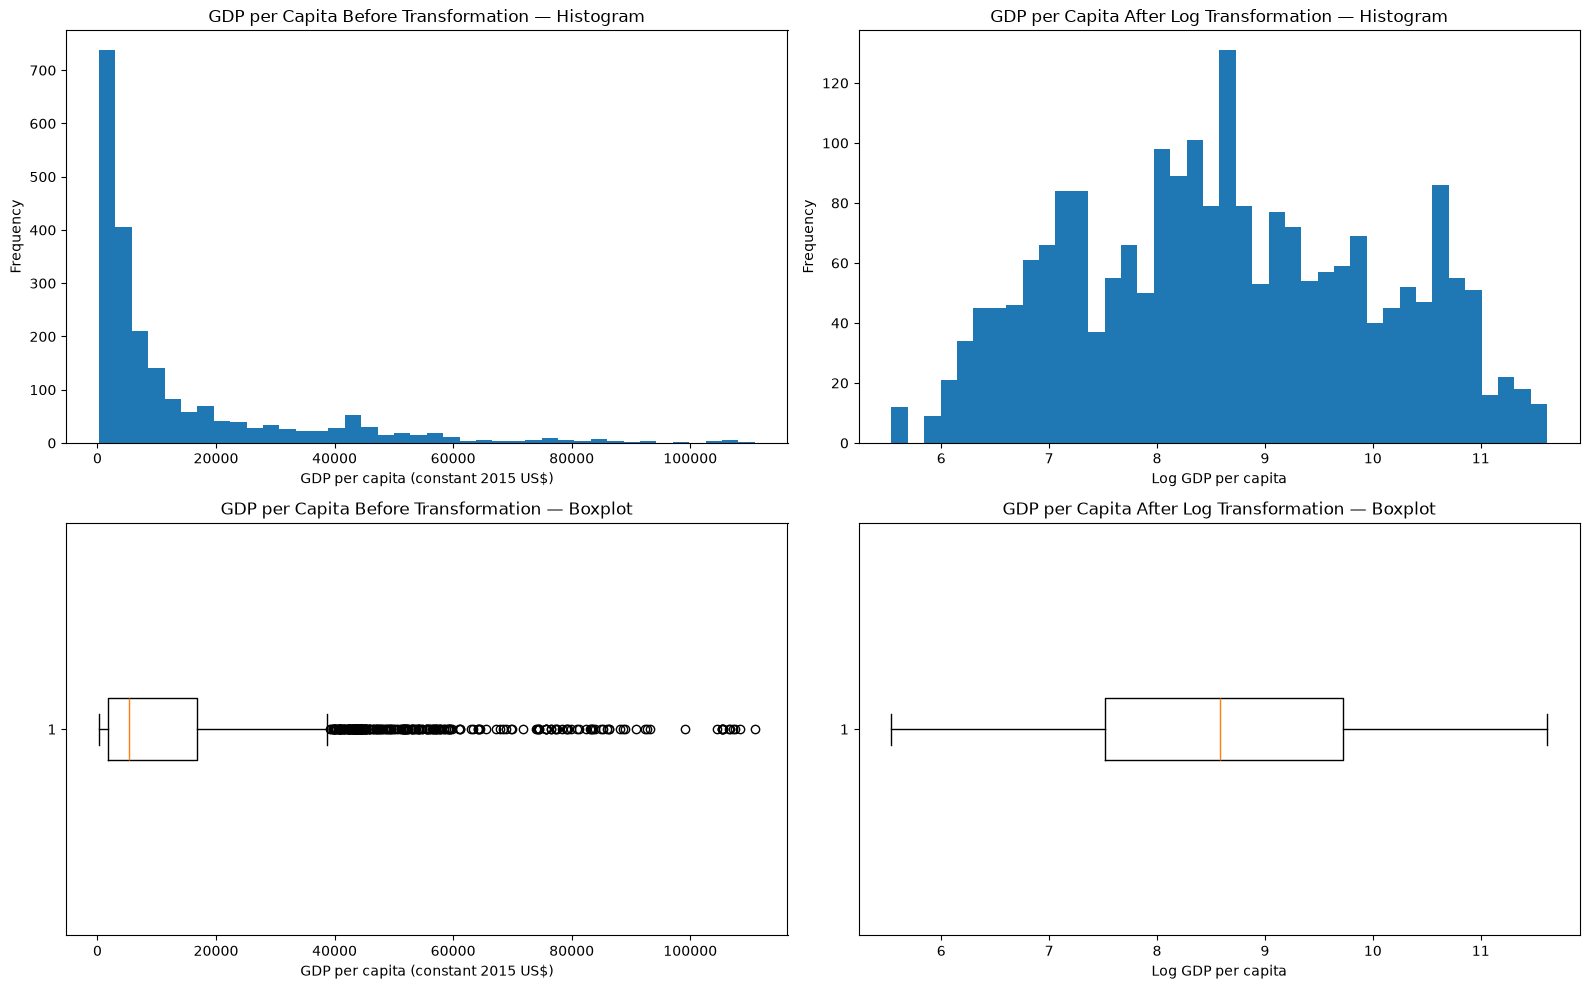

In [253]:
gdp = df_countries['gdp_per_capita_constant_2015_us']

# Log transformation
df_countries['gdp_per_capita_constant_2015_us_log'] = np.log1p(gdp)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# =========================
# BEFORE — Histogram
# =========================
axes[0, 0].hist(
    gdp.dropna(),
    bins=40
)
axes[0, 0].set_title('GDP per Capita Before Transformation — Histogram')
axes[0, 0].set_xlabel('GDP per capita (constant 2015 US$)')
axes[0, 0].set_ylabel('Frequency')

# =========================
# AFTER — Histogram
# =========================
axes[0, 1].hist(
    df_countries['gdp_per_capita_constant_2015_us_log'].dropna(),
    bins=40
)
axes[0, 1].set_title('GDP per Capita After Log Transformation — Histogram')
axes[0, 1].set_xlabel('Log GDP per capita')
axes[0, 1].set_ylabel('Frequency')

# =========================
# BEFORE — Boxplot
# =========================
axes[1, 0].boxplot(
    gdp.dropna(),
    vert=False
)
axes[1, 0].set_title('GDP per Capita Before Transformation — Boxplot')
axes[1, 0].set_xlabel('GDP per capita (constant 2015 US$)')

# =========================
# AFTER — Boxplot
# =========================
axes[1, 1].boxplot(
    df_countries['gdp_per_capita_constant_2015_us_log'].dropna(),
    vert=False
)
axes[1, 1].set_title('GDP per Capita After Log Transformation — Boxplot')
axes[1, 1].set_xlabel('Log GDP per capita')

plt.tight_layout()
plt.show()

In [254]:
df_countries.drop(columns='gdp_per_capita_constant_2015_us', inplace=True)

In [255]:
df_countries['military_expenditure_of_general_government_expenditure_log'] = np.log1p(df_countries['military_expenditure_of_general_government_expenditure'])

In [256]:
df_countries.drop(columns='military_expenditure_of_general_government_expenditure', inplace=True)

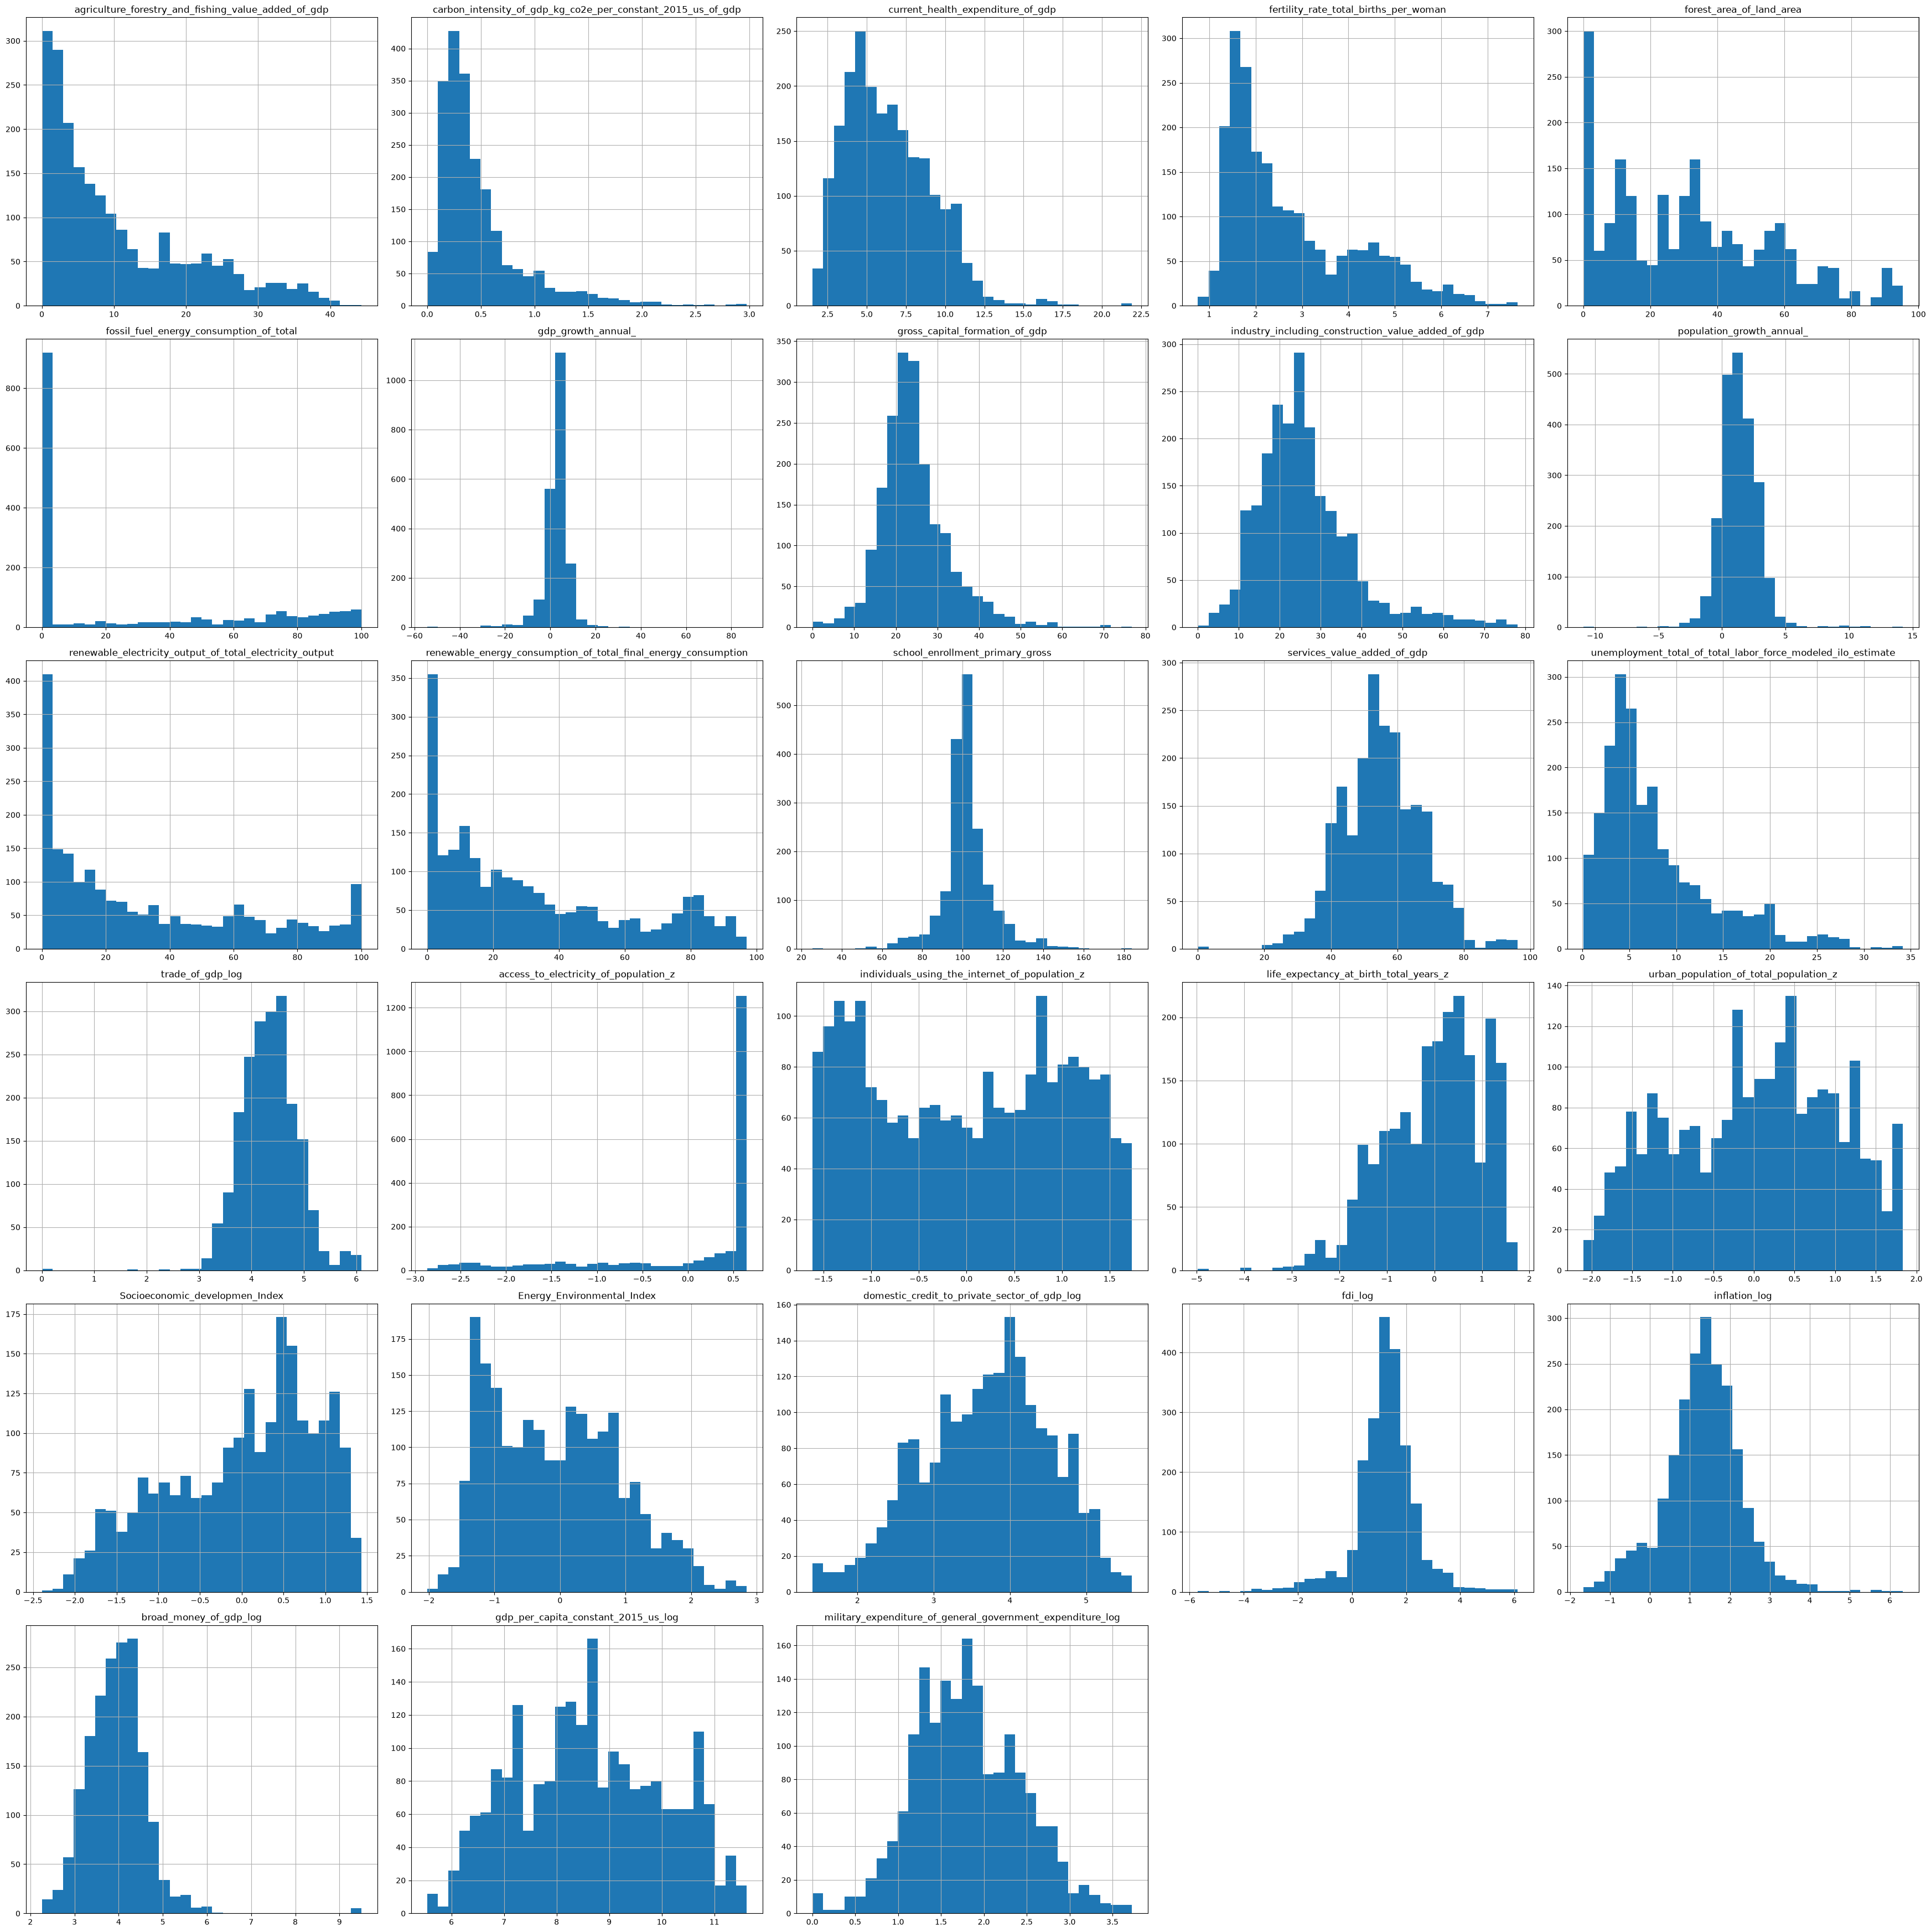

In [257]:
numeric_cols = df_countries.select_dtypes(include="number").columns.drop("year")

df_countries[numeric_cols].hist(
    figsize=(35, 35),
    bins=30
)

plt.tight_layout()
plt.show()

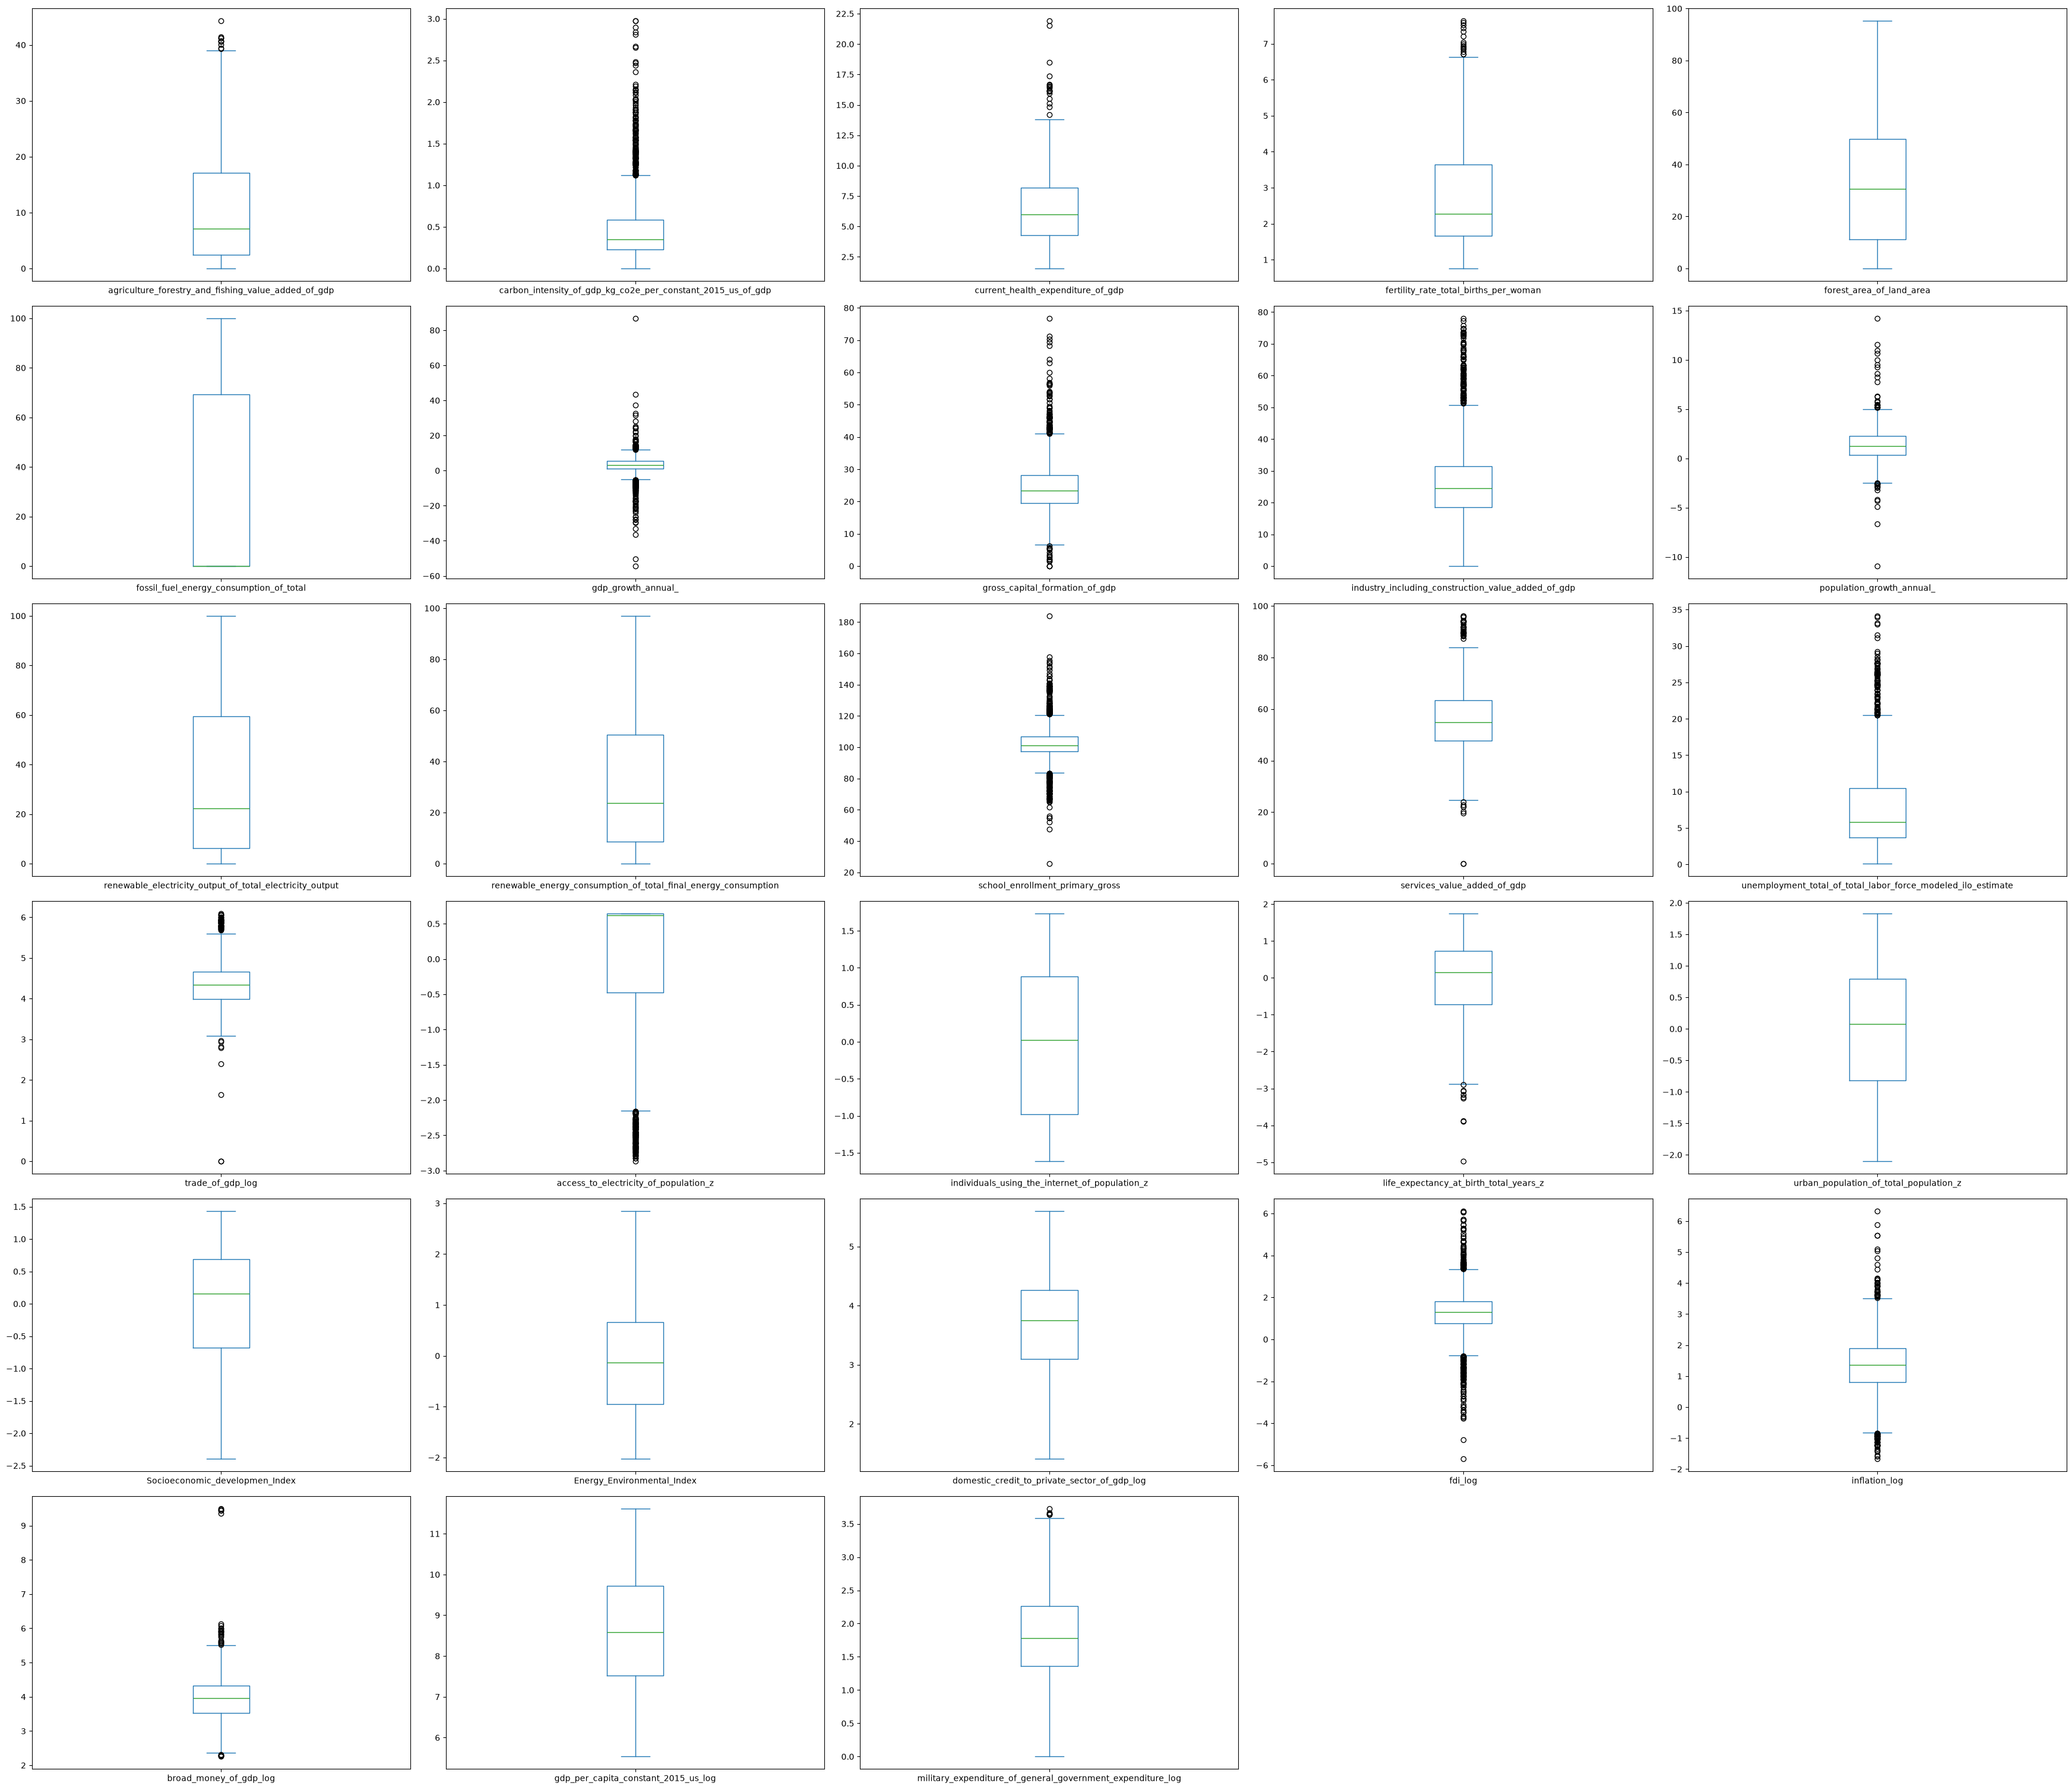

In [258]:
numeric_cols = df_countries.select_dtypes(include="number").columns.drop("year")

df_countries[numeric_cols].plot(
    kind="box",
    subplots=True,
    layout=(7, 5),
    figsize=(35, 35),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()

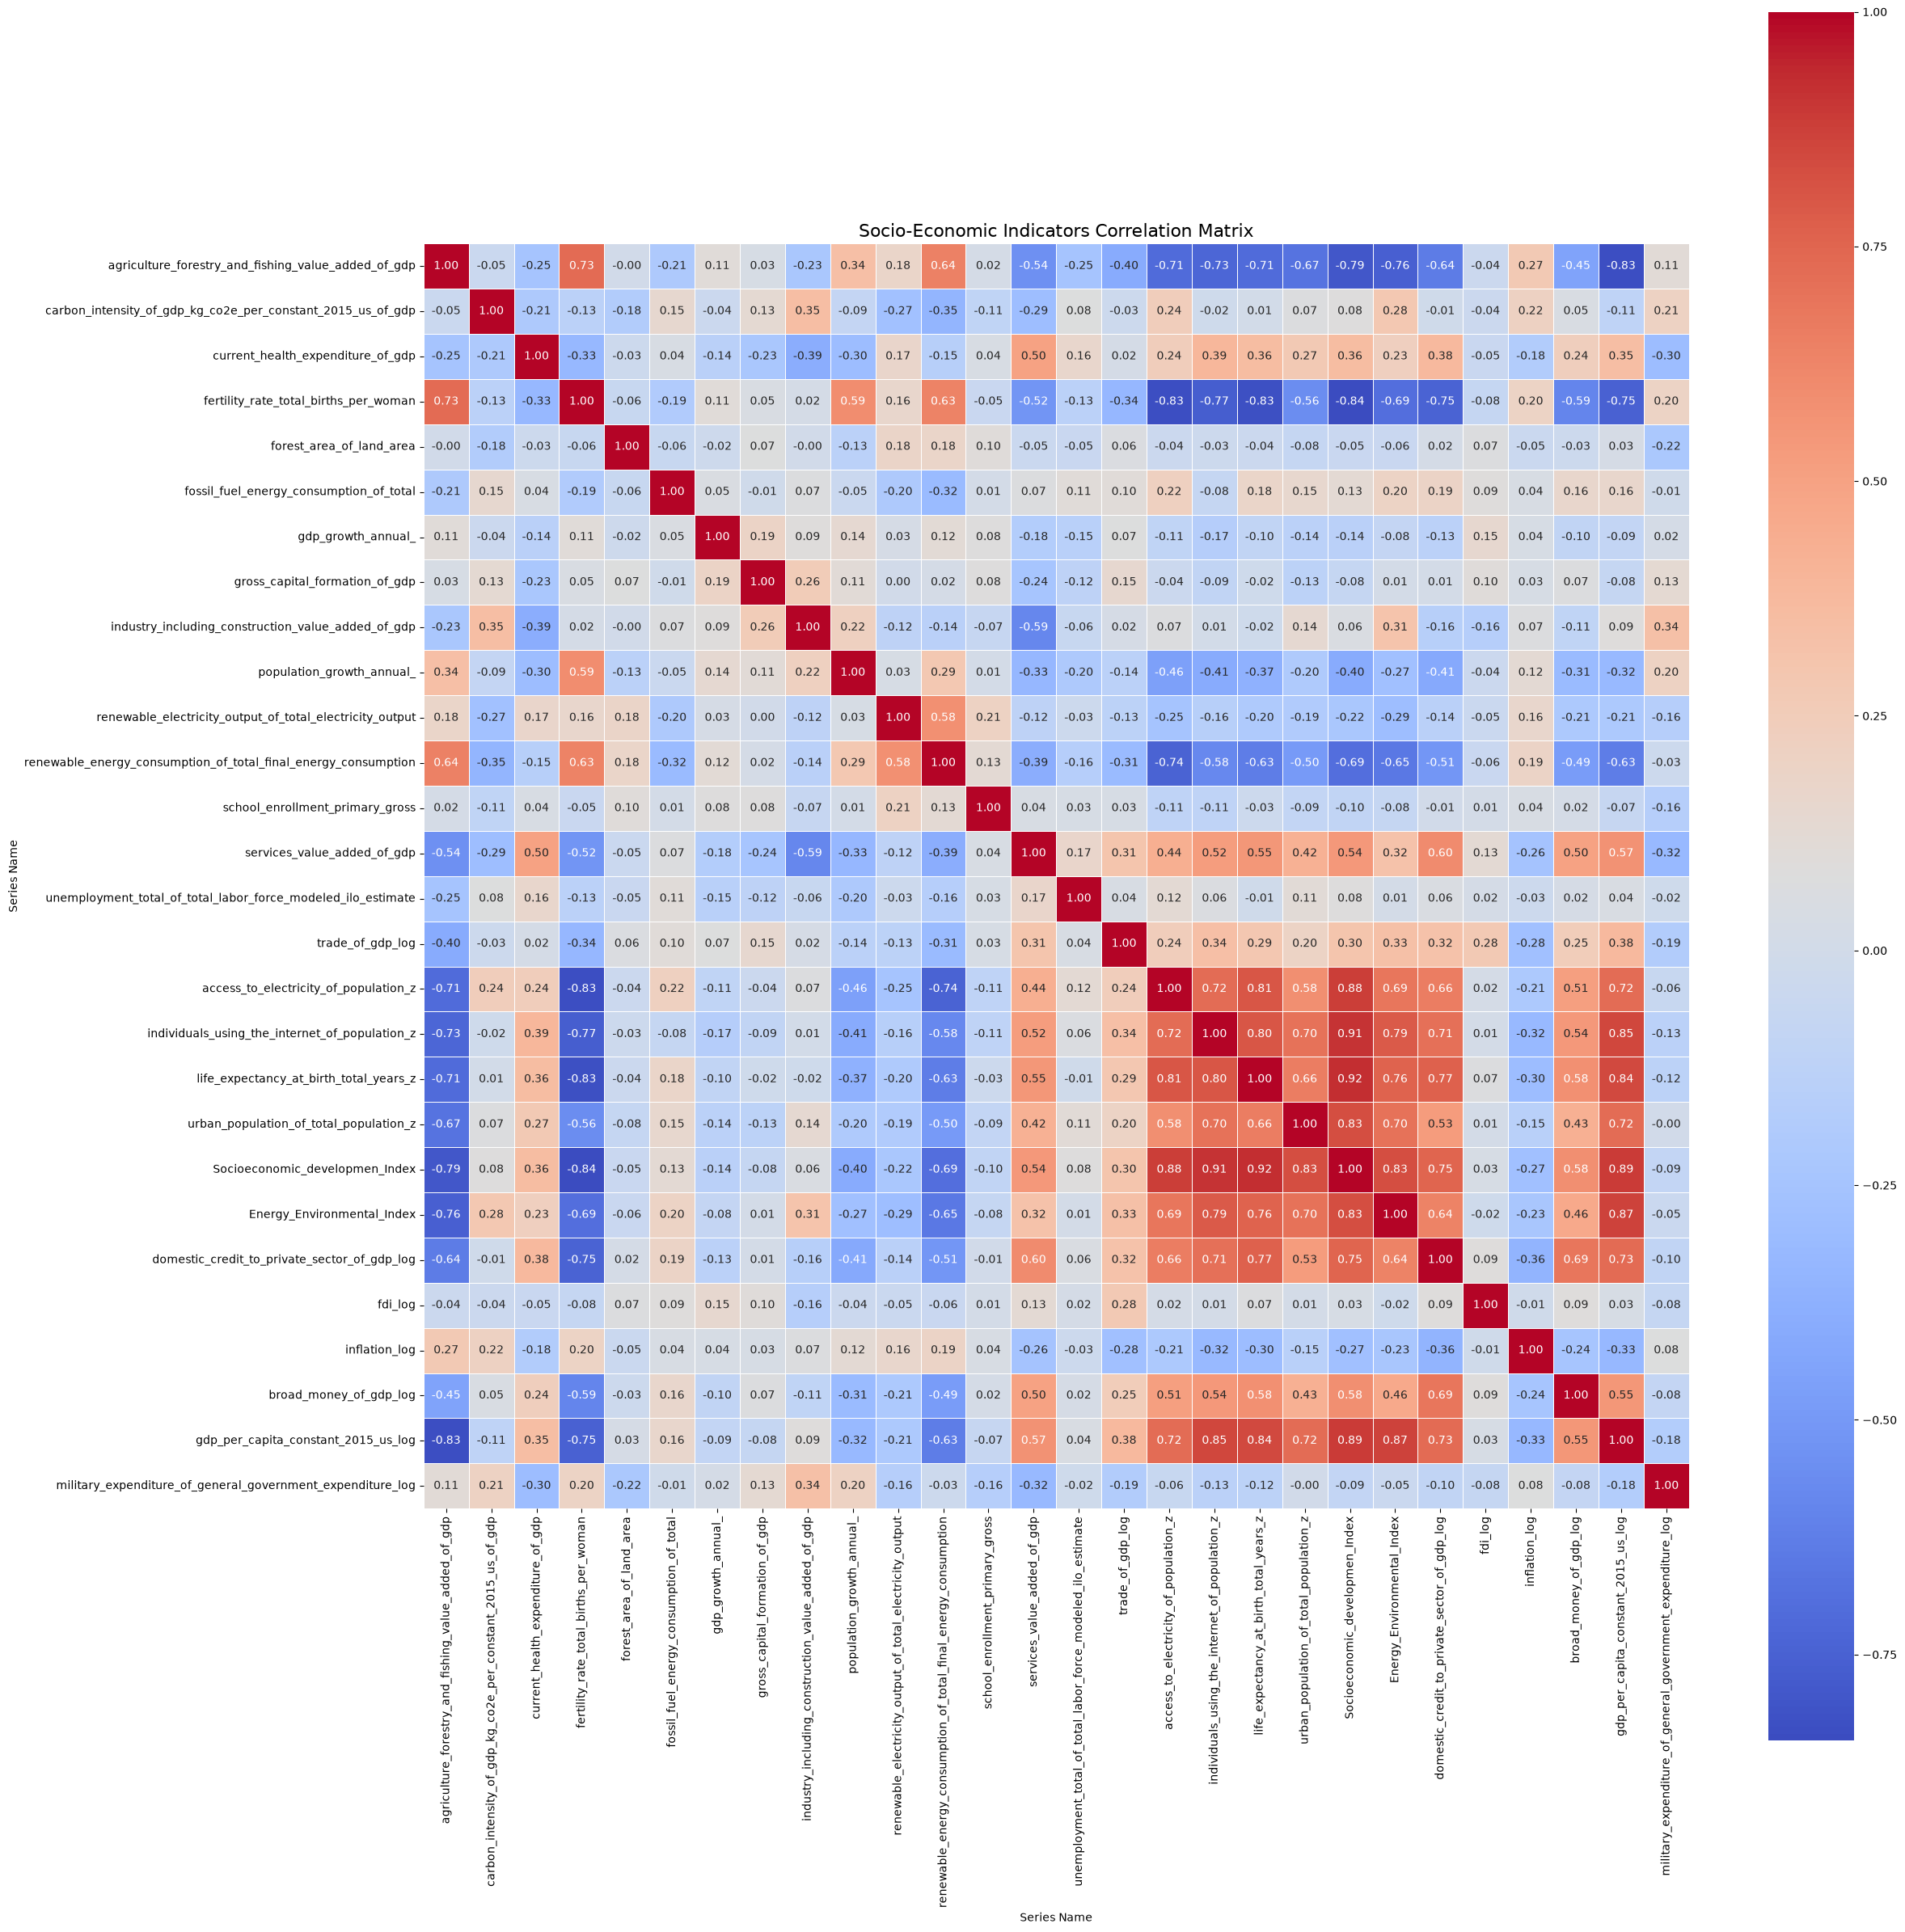

In [259]:
numeric_cols = df_countries.select_dtypes(include="number").columns.drop("year")

# 1. Compute the correlation matrix
corr_matrix = df_countries[numeric_cols].corr()

# 2. Plot the correlation matrix heatmap
plt.figure(figsize=(25, 25))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    square=True,
    linewidths=0.5
)

plt.title("Socio-Economic Indicators Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

In [260]:
df_describe2 = df_countries.iloc[:, 3:].describe()
df_describe2

Series Name,agriculture_forestry_and_fishing_value_added_of_gdp,carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp,current_health_expenditure_of_gdp,fertility_rate_total_births_per_woman,forest_area_of_land_area,fossil_fuel_energy_consumption_of_total,gdp_growth_annual_,gross_capital_formation_of_gdp,industry_including_construction_value_added_of_gdp,population_growth_annual_,...,life_expectancy_at_birth_total_years_z,urban_population_of_total_population_z,Socioeconomic_developmen_Index,Energy_Environmental_Index,domestic_credit_to_private_sector_of_gdp_log,fdi_log,inflation_log,broad_money_of_gdp_log,gdp_per_capita_constant_2015_us_log,military_expenditure_of_general_government_expenditure_log
count,2154.000000,2142.000000,2139.000000,2184.000000,2158.000000,1682.000000,2177.000000,1950.000000,2166.000000,2184.000000,...,2.184000e+03,2.184000e+03,2.184000e+03,2172.000000,1994.000000,2139.000000,2117.000000,1781.000000,2178.000000,1750.000000
mean,10.728903,0.481104,6.362456,2.756436,32.172623,29.828878,2.910329,24.540148,26.243296,1.324961,...,-3.367270e-16,9.760202e-17,-1.366428e-16,-0.072319,3.682237,1.265023,1.326131,3.953415,8.624285,1.813456
std,10.100060,0.409526,2.712920,1.384409,24.141298,37.200612,5.834001,8.478642,11.898625,1.497868,...,1.000229e+00,1.000229e+00,8.860740e-01,0.978894,0.844489,1.118983,0.946481,0.674641,1.398061,0.624494
min,0.000000,0.000590,1.543096,0.756000,0.000000,0.000000,-54.402093,0.000000,0.000000,-10.927442,...,-4.973103e+00,-2.101320e+00,-2.394345e+00,-2.026070,1.410157,-5.693777,-1.666739,2.260250,5.538548,0.002827
25%,2.392313,0.225890,4.275708,1.663500,11.122302,0.000000,1.200000,19.480333,18.528362,0.357824,...,-7.120805e-01,-8.189468e-01,-6.773743e-01,-0.955401,3.096712,0.773948,0.807832,3.533722,7.515986,1.357994
50%,7.105493,0.350282,6.004436,2.270500,30.675050,0.000000,3.237075,23.377209,24.507567,1.258048,...,1.470929e-01,7.676760e-02,1.557976e-01,-0.127677,3.748147,1.313676,1.363263,3.955529,8.584715,1.779996
75%,17.065236,0.584144,8.186075,3.650750,49.765447,69.352676,5.513420,28.099289,31.458753,2.247920,...,7.371956e-01,7.973518e-01,6.851203e-01,0.664127,4.263456,1.803177,1.894939,4.325120,9.727359,2.265107
max,44.330943,2.976524,21.923731,7.640000,95.321711,99.990788,86.826748,76.782325,78.064874,14.225399,...,1.747301e+00,1.832427e+00,1.432539e+00,2.846890,5.601518,6.116380,6.324721,9.496308,11.616151,3.729063
